# Experiment 3 - Observation-Frequency Distribution Shift

This notebook keeps strict validation-selected-checkpoint provenance and organizes Experiment 3 into four sub-experiments.

## Scientific Question

How much held-out performance is recovered when the training observation regime matches the deployment observation regime, and do related controls support that interpretation without changing the underlying model-selection rules?

## Experiment Definition

Sub-experiments:

- Exp3A. Structured observation-frequency shift: h=12, r={4,8}.
- Exp3B. Normalizer control: h=12, r=4.
- Exp3C. Random-matched observation-frequency shift: h=12, r=4.
- Exp3D. Longer-horizon replication: h=96, r=4.

All test predictions preserve the strict chain: validation log -> complete run -> validation-AUPRC-selected epoch -> exact selected checkpoint -> exact expected prediction filename.

In [1]:
EXP3_ALLOW_PARTIAL_RESULTS = True
EXP3_REQUIRE_COMPLETE_EPOCHS = False
# Missing test predictions are always generated automatically.
# Set this to True only when intentionally regenerating ALL test predictions.
RERUN_ALL_TEST_INFERENCE = False

## Configuration

The validation log/checkpoint filename verifies only fields encoded in the run name: model seed, horizon, timestep, train sampling regime, hidden dimension, dropout/rec_dropout tokens, depth, batch size, target-replication coefficient, and L1/L2 suffixes. The notebook applies strict mismatch checks only to those filename-verified fields.

The current result tree does not include a saved per-run argument/config artifact for fields such as `network`, `optimizer`, `lr`, `beta_1`, `imputation`, or `prefix`. Those fields are therefore assumed from the known Experiment 2/3 training configuration below and are labeled as experiment-config-assumed in the provenance tables. They are still used to reconstruct test-inference commands, but they are not presented as independently verified from the training run.


In [2]:
from pathlib import Path
import os
import re
import shlex
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_EXP3_REPO_IMPORT_DIR = Path.cwd().parent if Path.cwd().name == "visualizers" else Path.cwd()
if str(_EXP3_REPO_IMPORT_DIR) not in sys.path:
    sys.path.insert(0, str(_EXP3_REPO_IMPORT_DIR))

from mimic4benchmark.readers import FixedHorizonIcuExitReader
from mimic4models.fixed_horizon_icu_exit.matched_count_control.sampling import SamplingReader
from mimic4models.fixed_horizon_icu_exit.raw import RawSequenceEncoder

from visualize_utils import (
    DEFAULT_BOOTSTRAP_SEED,
    across_seed_patient_bootstrap,
    compute_metric,
    find_selected_checkpoint,
    load_prediction_csv,
    metric_difference,
    paired_patient_bootstrap,
    paired_prediction_frame,
    prediction_metrics,
    read_validation_log,
    show_table,
    summarize_with_t_ci,
)

PROJECT_DATA_ROOT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo"
)

EXP3_REPO_DIR = Path.cwd().parent if Path.cwd().name == "visualizers" else Path.cwd()
EXP3_PYTHON = os.environ.get("EXP3_PYTHON", "python")
EXP3_DATA_DIR = PROJECT_DATA_ROOT / "data/length-of-stay"
EXP3_NORMALIZER_DIR = PROJECT_DATA_ROOT / "normalizers"
EXP3_RESULTS_DIR = PROJECT_DATA_ROOT / "results/fixed_horizon_icu_exit"
EXP3_OUTPUT_DIR = EXP3_RESULTS_DIR / "plots"
EXP3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXP3_NETWORK = "mimic4models/keras_models/lstm.py"
NETWORK = EXP3_NETWORK
EXP3_HORIZONS = [12, 96]
EXP3_STRUCTURED_CONFIGS = {12: [4, 8], 96: [4]}
EXP3_RANDOM_MATCHED_CONFIGS = {12: [4]}
EXP3_NORMALIZER_CONTROL_CONFIGS = {12: [4]}
EXP3_RANDOM_MATCHED_SAMPLING_SEED = 100
EXP3_INCLUDE_OPTIONAL_RS_IF_AVAILABLE = False
EXP3_EXPECTED_MODEL_SEEDS = {0, 1, 2, 3, 4}
EXP3_EXPECTED_EPOCHS = 100
EXP3_TIMESTEP = 1.0
EXP3_METRICS = ["auroc", "auprc", "brier"]
EXP3_N_BOOT = int(os.environ.get("EXP3_N_BOOT", "2000"))
EXP3_BOOTSTRAP_SEED = DEFAULT_BOOTSTRAP_SEED

EXP3_FILENAME_VERIFIED_CONFIG_FIELDS = [
    "dim", "depth", "dropout", "rec_dropout", "batch_norm", "batch_size",
    "timestep", "horizon", "model_seed", "target_repl_coef", "l1", "l2",
    "train_sampling_strategy", "train_sampling_interval", "train_sampling_seed",
]
EXP3_EXPERIMENT_CONFIG_ASSUMED_FIELDS = [
    "network", "optimizer", "lr", "beta_1", "imputation", "prefix",
]
EXP3_RUN_CONFIG_ARTIFACT_PATH = None
EXP3_RUN_CONFIG_ARTIFACT_STATUS = "not found; non-filename fields use known Experiment 2/3 configuration"

EXP3_EXPECTED_CONFIG = {
    "network": EXP3_NETWORK,
    "dim": 16,
    "depth": 2,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_norm": False,
    "batch_size": 8,
    "timestep": EXP3_TIMESTEP,
    "target_repl_coef": 0.0,
    "l1": 0.0,
    "l2": 0.0,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "imputation": "previous",
    "prefix": "",
}

print("Experiment 3 horizons:", EXP3_HORIZONS)
print("Structured configs:", EXP3_STRUCTURED_CONFIGS)
print("Random-matched configs:", EXP3_RANDOM_MATCHED_CONFIGS)
print("Normalizer-control configs:", EXP3_NORMALIZER_CONTROL_CONFIGS)
print("Random-matched sampling seed:", EXP3_RANDOM_MATCHED_SAMPLING_SEED)
print("Expected model seeds:", sorted(EXP3_EXPECTED_MODEL_SEEDS))
print("Bootstrap draws:", EXP3_N_BOOT)
print("Partial final summaries allowed:", EXP3_ALLOW_PARTIAL_RESULTS)
print("Missing test predictions: AUTO-RUN")
print("Rerun all existing test predictions:", RERUN_ALL_TEST_INFERENCE)
if RERUN_ALL_TEST_INFERENCE:
    print("WARNING: ALL eligible test predictions will be regenerated.")
print("Filename-verified config fields:", EXP3_FILENAME_VERIFIED_CONFIG_FIELDS)
print("Experiment-config-assumed fields:", EXP3_EXPERIMENT_CONFIG_ASSUMED_FIELDS)
print("Run/config artifact status:", EXP3_RUN_CONFIG_ARTIFACT_STATUS)

Experiment 3 horizons: [12, 96]
Structured configs: {12: [4, 8], 96: [4]}
Random-matched configs: {12: [4]}
Normalizer-control configs: {12: [4]}
Random-matched sampling seed: 100
Expected model seeds: [0, 1, 2, 3, 4]
Bootstrap draws: 2000
Partial final summaries allowed: True
Missing test predictions: AUTO-RUN
Rerun all existing test predictions: False
Filename-verified config fields: ['dim', 'depth', 'dropout', 'rec_dropout', 'batch_norm', 'batch_size', 'timestep', 'horizon', 'model_seed', 'target_repl_coef', 'l1', 'l2', 'train_sampling_strategy', 'train_sampling_interval', 'train_sampling_seed']
Experiment-config-assumed fields: ['network', 'optimizer', 'lr', 'beta_1', 'imputation', 'prefix']
Run/config artifact status: not found; non-filename fields use known Experiment 2/3 configuration


## Run discovery and provenance

The discovery code follows the old notebook provenance chain:

`validation log -> validation-AUPRC-selected epoch -> exact checkpoint filename -> exact test prediction filename`

Matched-regime predictions must use the original filename `<checkpoint>.csv`. Shifted predictions must use an explicit `.testsample-...` suffix. The test regime is never inferred from directory name alone, and file modification time is never used.

In [3]:
def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    return cast(value) if cast is not None else value


def parse_sampling_from_name(name):
    sample = re.search(
        r"\.sample(?P<strategy>structured|random_matched)"
        r"\.r(?P<interval>\d+)"
        r"(?:\.sseed(?P<sseed>\d+))?",
        name,
    )
    if sample is None:
        return "none", None, None
    strategy = sample.group("strategy")
    interval = int(sample.group("interval"))
    seed = sample.group("sseed")
    return strategy, interval, int(seed) if seed is not None else None


def parse_exp3_log_name(log_path, normalizer_regime="train_matched"):
    name = log_path.name
    strategy, interval, sampling_seed = parse_sampling_from_name(name)
    l1 = _search(r"\.L1([0-9.eE+-]+)(?=\.|$)", name, float, 0.0)
    l2 = _search(r"\.L2([0-9.eE+-]+)(?=\.|$)", name, float, 0.0)
    return {
        "filename": name,
        "horizon": _search(r"\.h(\d+)", name, int),
        "timestep": _search(r"\.ts([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float),
        "model_seed": _search(r"\.seed(\d+)(?:\.|$)", name, int),
        "train_sampling_strategy": strategy,
        "train_sampling_interval": interval,
        "train_sampling_seed": sampling_seed,
        "normalizer_regime": normalizer_regime,
        "dim": _search(r"\.n(\d+)", name, int),
        "dropout": _search(r"\.d([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "rec_dropout": _search(r"\.rd([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "batch_norm": re.search(r"\.bn(?=\.|$)", name) is not None,
        "depth": _search(r"\.dep(\d+)", name, int),
        "batch_size": _search(r"\.bs(\d+)", name, int),
        "target_repl_coef": _search(r"\.trc([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "l1": l1,
        "l2": l2,
        "has_l1": l1 > 0,
        "has_l2": l2 > 0,
        "log_path": str(log_path),
        "output_dir": str(log_path.parent.parent),
    }


def effective_sampling_regime(strategy, interval, seed):
    if strategy == "none":
        return ("none",)
    if strategy == "structured":
        return ("structured", int(interval))
    if strategy == "random_matched":
        return ("random_matched", int(interval), seed)
    raise ValueError("Unknown sampling strategy {}".format(strategy))


def regimes_match(train_strategy, train_interval, train_seed, test_strategy, test_interval, test_seed):
    return effective_sampling_regime(train_strategy, train_interval, train_seed) == effective_sampling_regime(
        test_strategy, test_interval, test_seed)


def sampling_label(strategy, interval, seed=None):
    if strategy == "none":
        return "dense"
    if strategy == "structured":
        return "structured-r{}".format(int(interval))
    if strategy == "random_matched":
        return "random-r{}".format(int(interval))
    raise ValueError("Unknown sampling strategy {}".format(strategy))


def regime_label(train_strategy, train_interval, test_strategy, test_interval):
    return "{}->{}".format(
        sampling_label(train_strategy, train_interval),
        sampling_label(test_strategy, test_interval),
    )


def test_sampling_suffix(strategy, interval, seed):
    if strategy == "none":
        return "testsample-none"
    label = "testsample-{}-r{}".format(strategy, int(interval))
    if strategy == "random_matched":
        label += "-sseed{}".format(seed)
    return label


def expected_prediction_path(output_dir, checkpoint, train_strategy, train_interval, train_seed,
                             test_strategy, test_interval, test_seed):
    pred_dir = Path(output_dir) / "test_predictions"
    base = pred_dir / checkpoint.name
    if regimes_match(train_strategy, train_interval, train_seed, test_strategy, test_interval, test_seed):
        return Path(str(base) + ".csv")
    return Path(str(base) + ".{}.csv".format(test_sampling_suffix(test_strategy, test_interval, test_seed)))


def parse_prediction_test_regime(prediction_path, checkpoint, train_strategy, train_interval, train_seed):
    name = Path(prediction_path).name
    matched_name = checkpoint.name + ".csv"
    if name == matched_name:
        return train_strategy, train_interval, train_seed, "matched-original-filename"
    prefix = checkpoint.name + ".testsample-"
    if not (name.startswith(prefix) and name.endswith(".csv")):
        raise ValueError("Prediction file does not match checkpoint naming convention: {}".format(prediction_path))
    label = name[len(prefix):-4]
    if label == "none":
        return "none", None, None, "explicit-testsample-suffix"
    m = re.match(r"(?P<strategy>structured|random_matched)-r(?P<interval>\d+)(?:-sseed(?P<seed>\d+))?$", label)
    if m is None:
        raise ValueError("Unrecognized test-sampling suffix in {}".format(prediction_path))
    strategy = m.group("strategy")
    interval = int(m.group("interval"))
    seed = m.group("seed")
    return strategy, interval, int(seed) if seed is not None else None, "explicit-testsample-suffix"


def _float_mismatch(actual, expected, tol=1e-9):
    if actual is None:
        return True
    return abs(float(actual) - float(expected)) > tol


def attach_assumed_experiment_config(run):
    run = dict(run)
    for key in EXP3_EXPERIMENT_CONFIG_ASSUMED_FIELDS:
        run[key] = EXP3_EXPECTED_CONFIG[key]
        run["{}_source".format(key)] = "experiment-config-assumed"
    for key in EXP3_FILENAME_VERIFIED_CONFIG_FIELDS:
        run["{}_source".format(key)] = "filename-verified"
    run["filename_verified_config_fields"] = ", ".join(EXP3_FILENAME_VERIFIED_CONFIG_FIELDS)
    run["experiment_config_assumed_fields"] = ", ".join(EXP3_EXPERIMENT_CONFIG_ASSUMED_FIELDS)
    run["run_config_artifact_path"] = EXP3_RUN_CONFIG_ARTIFACT_PATH
    run["run_config_artifact_status"] = EXP3_RUN_CONFIG_ARTIFACT_STATUS
    return run


def hyperparameter_mismatch_reason(run):
    reasons = []
    for key in ["dim", "depth", "batch_size"]:
        if run.get(key) != EXP3_EXPECTED_CONFIG[key]:
            reasons.append("{}={} expected {}".format(key, run.get(key), EXP3_EXPECTED_CONFIG[key]))
    for key in ["dropout", "rec_dropout", "target_repl_coef", "l1", "l2", "timestep"]:
        if _float_mismatch(run.get(key), EXP3_EXPECTED_CONFIG[key]):
            reasons.append("{}={} expected {}".format(key, run.get(key), EXP3_EXPECTED_CONFIG[key]))
    if run.get("horizon") not in EXP3_HORIZONS:
        reasons.append("horizon={} not in expected {}".format(run.get("horizon"), EXP3_HORIZONS))
    if bool(run.get("batch_norm")) != bool(EXP3_EXPECTED_CONFIG["batch_norm"]):
        reasons.append("batch_norm={} expected {}".format(run.get("batch_norm"), EXP3_EXPECTED_CONFIG["batch_norm"]))
    if run.get("model_seed") not in EXP3_EXPECTED_MODEL_SEEDS:
        reasons.append("model_seed={} not in expected {}".format(run.get("model_seed"), sorted(EXP3_EXPECTED_MODEL_SEEDS)))
    return "; ".join(reasons)


def normalizer_candidates_for_regime(strategy, interval, seed):
    if strategy == "none":
        pattern = "fixed_horizon_icu_exit_ts:{:.2f}_impute:{}_start:zero_masks:True_n:*.normalizer".format(
            EXP3_TIMESTEP, EXP3_EXPECTED_CONFIG["imputation"])
    elif strategy == "structured":
        pattern = (
            "fixed_horizon_icu_exit_sampling:structured_r:{}_ts:{:.2f}"
            "_impute:{}_start:zero_masks:True_n:*.normalizer"
        ).format(int(interval), EXP3_TIMESTEP, EXP3_EXPECTED_CONFIG["imputation"])
    elif strategy == "random_matched":
        pattern = (
            "fixed_horizon_icu_exit_sampling:random_matched_r:{}_seed:{}_ts:{:.2f}"
            "_impute:{}_start:zero_masks:True_n:*.normalizer"
        ).format(int(interval), int(seed), EXP3_TIMESTEP, EXP3_EXPECTED_CONFIG["imputation"])
    else:
        raise ValueError("Unknown normalizer strategy {}".format(strategy))
    return sorted(EXP3_NORMALIZER_DIR.glob(pattern))


def resolve_normalizer_for_regime(strategy, interval, seed):
    candidates = normalizer_candidates_for_regime(strategy, interval, seed)
    if len(candidates) != 1:
        raise RuntimeError(
            "Expected exactly one normalizer for {} but found {}: {}".format(
                effective_sampling_regime(strategy, interval, seed), len(candidates), [str(x) for x in candidates]))
    return candidates[0]


def resolve_normalizer_for_run(train_strategy, train_interval, train_seed, normalizer_regime):
    if normalizer_regime == "dense":
        return resolve_normalizer_for_regime("none", None, None)
    if normalizer_regime == "train_matched":
        return resolve_normalizer_for_regime(train_strategy, train_interval, train_seed)
    raise ValueError("Unknown normalizer_regime {}".format(normalizer_regime))


def quote_command(cmd):
    return " ".join(shlex.quote(str(x)) for x in cmd)


def prediction_identity(row):
    return (
        int(row["horizon"]),
        row["train_sampling_strategy"],
        None if pd.isnull(row["train_sampling_interval"]) else int(row["train_sampling_interval"]),
        None if pd.isnull(row["train_sampling_seed"]) else int(row["train_sampling_seed"]),
        row["test_sampling_strategy"],
        None if pd.isnull(row["test_sampling_interval"]) else int(row["test_sampling_interval"]),
        None if pd.isnull(row["test_sampling_seed"]) else int(row["test_sampling_seed"]),
        row["normalizer_regime"],
        int(row["model_seed"]),
    )


def build_inference_command_parts(row):
    normalizer_path = row.get("normalizer_path")
    if not normalizer_path:
        normalizer_path = str(resolve_normalizer_for_run(
            row["train_sampling_strategy"], row["train_sampling_interval"],
            row["train_sampling_seed"], row["normalizer_regime"]))
    cmd = [
        EXP3_PYTHON, "-m", "mimic4models.fixed_horizon_icu_exit.main",
        "--mode", "test",
        "--network", row["network"],
        "--data", str(EXP3_DATA_DIR),
        "--normalizer_dir", str(EXP3_NORMALIZER_DIR),
        "--normalizer_state", str(normalizer_path),
        "--output_dir", row["output_dir"],
        "--load_state", row["checkpoint_path"],
        "--horizon", str(int(row["horizon"])),
        "--timestep", str(row["timestep"]),
        "--seed", str(int(row["model_seed"])),
        "--dim", str(int(row["dim"])),
        "--depth", str(int(row["depth"])),
        "--dropout", str(row["dropout"]),
        "--rec_dropout", str(row["rec_dropout"]),
        "--batch_size", str(int(row["batch_size"])),
        "--target_repl_coef", str(row["target_repl_coef"]),
        "--l1", str(row["l1"]),
        "--l2", str(row["l2"]),
        "--optimizer", row["optimizer"],
        "--lr", str(row["lr"]),
        "--beta_1", str(row["beta_1"]),
        "--imputation", row["imputation"],
        "--prefix", row["prefix"],
        "--sampling_strategy", row["train_sampling_strategy"],
    ]
    if bool(row.get("batch_norm")):
        cmd += ["--batch_norm", "True"]
    if row["train_sampling_strategy"] != "none":
        cmd += ["--sampling_interval", str(int(row["train_sampling_interval"]))]
    if row["train_sampling_seed"] is not None and not pd.isnull(row["train_sampling_seed"]):
        cmd += ["--sampling_seed", str(int(row["train_sampling_seed"]))]
    if not regimes_match(row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
                         row["test_sampling_strategy"], row["test_sampling_interval"], row["test_sampling_seed"]):
        cmd += ["--test_sampling_strategy", row["test_sampling_strategy"]]
        if row["test_sampling_strategy"] != "none":
            cmd += ["--test_sampling_interval", str(int(row["test_sampling_interval"]))]
        if row["test_sampling_seed"] is not None and not pd.isnull(row["test_sampling_seed"]):
            cmd += ["--test_sampling_seed", str(int(row["test_sampling_seed"]))]
    return cmd


def build_missing_inference_command(row):
    return quote_command(build_inference_command_parts(row))


def run_test_inference_for_row(row):
    cmd = build_inference_command_parts(row)
    prediction_path = Path(row["expected_prediction_path"])
    if prediction_path.exists():
        if not RERUN_ALL_TEST_INFERENCE:
            return
        print("RERUN_ALL_TEST_INFERENCE=True")
        print("Regenerating existing prediction:")
        print(prediction_path)
    else:
        print("Missing test prediction; running inference:")
        print(prediction_path)
    print("  experiment/subexperiment:", row["experiment"])
    print("  horizon:", row["horizon"])
    print("  model seed:", row["model_seed"])
    print("  train sampling regime:", effective_sampling_regime(row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"]))
    print("  test sampling regime:", effective_sampling_regime(row["test_sampling_strategy"], row["test_sampling_interval"], row["test_sampling_seed"]))
    print("  normalizer regime/path:", row["normalizer_regime"], row["normalizer_path"])
    print("  selected epoch:", row["selected_val_epoch"])
    print("  checkpoint:", row["checkpoint_path"])
    print("  exact expected prediction path:", prediction_path)
    print("  command:", quote_command(cmd))
    subprocess.check_call(cmd, cwd=str(EXP3_REPO_DIR))
    if not prediction_path.exists():
        raise RuntimeError("Test inference completed but exact prediction file is missing: {}".format(prediction_path))

In [4]:
def log_dir_for_run_kind(kind, horizon, r=None):
    if kind == "dense":
        return EXP3_RESULTS_DIR / "{}h".format(int(horizon)) / "keras_logs"
    if kind == "structured":
        return EXP3_RESULTS_DIR / "structured" / "{}h".format(int(horizon)) / "{}h".format(int(r)) / "keras_logs"
    if kind == "random_matched":
        return EXP3_RESULTS_DIR / "random_matched" / "{}h".format(int(horizon)) / "{}h".format(int(r)) / "keras_logs"
    if kind == "normalizer_control_dense":
        return EXP3_RESULTS_DIR / "structured_r4_dense_norm_control" / "{}h".format(int(horizon)) / "keras_logs"
    raise ValueError("Unknown run kind {}".format(kind))


def requested_train_sources():
    sources = []
    needed_horizons = set(EXP3_HORIZONS)
    for horizon in sorted(needed_horizons):
        sources.append({"kind": "dense", "horizon": horizon, "r": None, "normalizer_regime": "train_matched"})
    for horizon, rs in EXP3_STRUCTURED_CONFIGS.items():
        for r in rs:
            sources.append({"kind": "structured", "horizon": horizon, "r": r, "normalizer_regime": "train_matched"})
    for horizon, rs in EXP3_RANDOM_MATCHED_CONFIGS.items():
        for r in rs:
            sources.append({"kind": "random_matched", "horizon": horizon, "r": r, "normalizer_regime": "train_matched"})
    for horizon, rs in EXP3_NORMALIZER_CONTROL_CONFIGS.items():
        for r in rs:
            sources.append({"kind": "normalizer_control_dense", "horizon": horizon, "r": r, "normalizer_regime": "dense"})
    return sources


train_status_rows = []
train_excluded_rows = []
train_runs = {}

for source in requested_train_sources():
    log_dir = log_dir_for_run_kind(source["kind"], source["horizon"], source["r"])
    print("Scanning {} logs:".format(source["kind"]), log_dir)
    if not log_dir.exists():
        row = dict(source)
        row["exclude_reason"] = "missing log directory"
        row["log_path"] = str(log_dir)
        train_excluded_rows.append(row)
        continue
    for log_path in sorted(log_dir.glob("*.csv")):
        parsed = attach_assumed_experiment_config(parse_exp3_log_name(log_path, source["normalizer_regime"]))
        parsed["run_kind"] = source["kind"]
        parsed["source_r"] = source["r"]
        if parsed["horizon"] != source["horizon"]:
            continue
        train_strategy = parsed["train_sampling_strategy"]
        train_interval = parsed["train_sampling_interval"]
        train_seed = parsed["train_sampling_seed"]
        is_requested = False
        if source["kind"] == "dense":
            is_requested = train_strategy == "none" and abs(parsed["timestep"] - EXP3_TIMESTEP) <= 1e-6
        elif source["kind"] == "structured":
            is_requested = (train_strategy == "structured" and train_interval == source["r"]
                            and abs(parsed["timestep"] - EXP3_TIMESTEP) <= 1e-6)
        elif source["kind"] == "random_matched":
            is_requested = (train_strategy == "random_matched" and train_interval == source["r"]
                            and train_seed == EXP3_RANDOM_MATCHED_SAMPLING_SEED
                            and abs(parsed["timestep"] - EXP3_TIMESTEP) <= 1e-6)
        elif source["kind"] == "normalizer_control_dense":
            is_requested = (train_strategy == "structured" and train_interval == source["r"]
                            and abs(parsed["timestep"] - EXP3_TIMESTEP) <= 1e-6)
        if not is_requested:
            row = dict(parsed)
            row["exclude_reason"] = "outside requested Experiment 3 train regimes"
            train_excluded_rows.append(row)
            continue

        mismatch = hyperparameter_mismatch_reason(parsed)
        if mismatch:
            row = dict(parsed)
            row["exclude_reason"] = mismatch
            train_excluded_rows.append(row)
            continue

        val = read_validation_log(log_path, expected_epochs=EXP3_EXPECTED_EPOCHS)
        if val is None:
            row = dict(parsed)
            row["exclude_reason"] = "empty validation log"
            train_excluded_rows.append(row)
            continue
        parsed.update(val)
        parsed["selected_val_epoch"] = parsed["selected_validation_epoch"]
        parsed["selected_val_auprc"] = parsed["validation_auprc"]
        parsed["selected_val_auroc"] = parsed["validation_auroc"]
        checkpoint = find_selected_checkpoint(log_path, parsed["selected_validation_epoch"])
        parsed["checkpoint_path"] = None if checkpoint is None else str(checkpoint)
        parsed["checkpoint_name"] = None if checkpoint is None else checkpoint.name
        normalizer = resolve_normalizer_for_run(
            train_strategy, train_interval, parsed["train_sampling_seed"], parsed["normalizer_regime"])
        parsed["normalizer_path"] = str(normalizer)
        parsed["normalizer_candidates"] = [str(normalizer)]
        train_status_rows.append(dict(parsed))

        if EXP3_REQUIRE_COMPLETE_EPOCHS and not parsed["complete"]:
            row = dict(parsed)
            row["exclude_reason"] = "incomplete epoch set; require exact 0..99"
            train_excluded_rows.append(row)
            continue
        if checkpoint is None:
            row = dict(parsed)
            row["exclude_reason"] = "missing validation-selected checkpoint"
            train_excluded_rows.append(row)
            continue

        key = (
            int(parsed["horizon"]), train_strategy, train_interval, parsed["train_sampling_seed"],
            parsed["normalizer_regime"], int(parsed["model_seed"]), source["kind"])
        if key in train_runs:
            raise RuntimeError("Duplicate train-run identity {}:\n{}\n{}".format(
                key, train_runs[key]["log_path"], parsed["log_path"]))
        train_runs[key] = parsed

exp3_train_status = pd.DataFrame(train_status_rows)
exp3_train_excluded = pd.DataFrame(train_excluded_rows)
show_table("Experiment 3 train-run status", exp3_train_status, max_rows=300)
show_table("Experiment 3 excluded train logs", exp3_train_excluded, max_rows=300)

Scanning dense logs: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h/keras_logs
Scanning dense logs: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/96h/keras_logs
Scanning structured logs: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured/12h/4h/keras_logs
Scanning structured logs: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured/12h/8h/keras_logs
Scanning structured logs: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured/96h/4h/keras_logs
Scanning random_matched logs: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_

,batch_norm,batch_norm_source,batch_size,batch_size_source,best_csv_epoch,best_val_auprc,best_val_epoch,beta_1,beta_1_source,checkpoint_epoch,...,train_sampling_interval_source,train_sampling_seed,train_sampling_seed_source,train_sampling_strategy,train_sampling_strategy_source,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,False,filename-verified,8,filename-verified,93,0.469834,93,0.9,experiment-config-assumed,94,...,filename-verified,NaN,filename-verified,none,filename-verified,0.469834,0.730083,0.730083,0.469834,0.730083
1,False,filename-verified,8,filename-verified,44,0.476230,44,0.9,experiment-config-assumed,45,...,filename-verified,NaN,filename-verified,none,filename-verified,0.476230,0.731720,0.731720,0.476230,0.731720
2,False,filename-verified,8,filename-verified,91,0.471504,91,0.9,experiment-config-assumed,92,...,filename-verified,NaN,filename-verified,none,filename-verified,0.471504,0.736019,0.736019,0.471504,0.736019
3,False,filename-verified,8,filename-verified,92,0.471724,92,0.9,experiment-config-assumed,93,...,filename-verified,NaN,filename-verified,none,filename-verified,0.471724,0.732311,0.732311,0.471724,0.732311
4,False,filename-verified,8,filename-verified,86,0.479264,86,0.9,experiment-config-assumed,87,...,filename-verified,NaN,filename-verified,none,filename-verified,0.479264,0.734050,0.734050,0.479264,0.734050
5,False,filename-verified,8,filename-verified,21,0.926869,21,0.9,experiment-config-assumed,22,...,filename-verified,NaN,filename-verified,none,filename-verified,0.926869,0.750883,0.750883,0.926869,0.750883
6,False,filename-verified,8,filename-verified,49,0.927035,49,0.9,experiment-config-assumed,50,...,filename-verified,NaN,filename-verified,none,filename-verified,0.927035,0.752676,0.752676,0.927035,0.752676
7,False,filename-verified,8,filename-verified,27,0.927492,27,0.9,experiment-config-assumed,28,...,filename-verified,NaN,filename-verified,none,filename-verified,0.927492,0.751650,0.751650,0.927492,0.751650
8,False,filename-verified,8,filename-verified,24,0.926640,24,0.9,experiment-config-assumed,25,...,filename-verified,NaN,filename-verified,none,filename-verified,0.926640,0.748562,0.748562,0.926640,0.748562
9,False,filename-verified,8,filename-verified,27,0.929675,27,0.9,experiment-config-assumed,28,...,filename-verified,NaN,filename-verified,none,filename-verified,0.929675,0.752615,0.752615,0.929675,0.752615



Experiment 3 excluded train logs


,batch_norm,batch_norm_source,batch_size,batch_size_source,beta_1,beta_1_source,depth,depth_source,dim,dim_source,...,target_repl_coef,target_repl_coef_source,timestep,timestep_source,train_sampling_interval,train_sampling_interval_source,train_sampling_seed,train_sampling_seed_source,train_sampling_strategy,train_sampling_strategy_source
0,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,1,filename-verified,16,filename-verified,...,0.0,filename-verified,1.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
1,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,1,filename-verified,16,filename-verified,...,0.0,filename-verified,1.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
2,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,1,filename-verified,16,filename-verified,...,0.0,filename-verified,1.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
3,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,1,filename-verified,16,filename-verified,...,0.0,filename-verified,1.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
4,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,1,filename-verified,16,filename-verified,...,0.0,filename-verified,1.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
5,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,2,filename-verified,16,filename-verified,...,0.0,filename-verified,12.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
6,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,2,filename-verified,16,filename-verified,...,0.0,filename-verified,12.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
7,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,2,filename-verified,16,filename-verified,...,0.0,filename-verified,12.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
8,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,2,filename-verified,16,filename-verified,...,0.0,filename-verified,12.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified
9,False,filename-verified,8,filename-verified,0.9,experiment-config-assumed,2,filename-verified,16,filename-verified,...,0.0,filename-verified,12.0,filename-verified,NaN,filename-verified,NaN,filename-verified,none,filename-verified


In [5]:
def train_key(horizon, strategy, interval, seed, normalizer_regime, kind, model_seed):
    return (int(horizon), strategy, interval, seed, normalizer_regime, int(model_seed), kind)


def get_train_run(horizon, strategy, interval, seed, normalizer_regime, kind, model_seed):
    return train_runs.get(train_key(horizon, strategy, interval, seed, normalizer_regime, kind, model_seed))


def _load_prediction_into_row(row, prediction_path, checkpoint):
    parsed_test_strategy, parsed_test_interval, parsed_test_seed, name_mode = parse_prediction_test_regime(
        prediction_path, checkpoint,
        row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"])
    expected_effective = effective_sampling_regime(
        row["test_sampling_strategy"], row["test_sampling_interval"], row["test_sampling_seed"])
    parsed_effective = effective_sampling_regime(parsed_test_strategy, parsed_test_interval, parsed_test_seed)
    if parsed_effective != expected_effective:
        raise RuntimeError("Prediction test-regime suffix mismatch for {}: parsed {} expected {}".format(
            prediction_path, parsed_effective, expected_effective))
    pred_df = load_prediction_csv(prediction_path)
    metrics = prediction_metrics(pred_df)
    row.update(metrics)
    row["prediction_path"] = str(prediction_path)
    row["prediction_status"] = "found"
    row["prediction_exists"] = True
    row["prediction_name_mode"] = name_mode
    row["missing_reason"] = None


def add_planned_eval(planned_rows, missing_rows, experiment, train_run, test_strategy, test_interval,
                     test_seed, condition_role, r, contrast_family):
    row = dict(train_run)
    row.update({
        "experiment": experiment,
        "test_sampling_strategy": test_strategy,
        "test_sampling_interval": test_interval,
        "test_sampling_seed": test_seed,
        "regime": regime_label(row["train_sampling_strategy"], row["train_sampling_interval"],
                               test_strategy, test_interval),
        "condition": condition_role,
        "contrast_family": contrast_family,
        "target_r": r,
    })
    checkpoint = Path(row["checkpoint_path"])
    prediction_path = expected_prediction_path(
        row["output_dir"], checkpoint,
        row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
        test_strategy, test_interval, test_seed,
    )
    row["expected_prediction_path"] = str(prediction_path)
    row["prediction_path"] = None
    row["prediction_status"] = "missing"
    row["prediction_exists"] = prediction_path.exists()
    row["prediction_name_mode"] = None
    row["missing_reason"] = None
    row["suggested_inference_command"] = build_missing_inference_command(row)
    row["prediction_key"] = prediction_identity(row)
    if prediction_path.exists():
        run_test_inference_for_row(row)
        row["prediction_exists"] = prediction_path.exists()
        _load_prediction_into_row(row, prediction_path, checkpoint)
    else:
        row["missing_reason"] = "missing exact prediction for selected checkpoint/test regime"
        run_test_inference_for_row(row)
        row["prediction_exists"] = prediction_path.exists()
        _load_prediction_into_row(row, prediction_path, checkpoint)
    planned_rows.append(row)


def maybe_add_eval(planned_rows, missing_rows, experiment, horizon, train_strategy, train_interval, train_seed,
                   normalizer_regime, kind, test_strategy, test_interval, test_seed,
                   condition_role, r, contrast_family, model_seed):
    train_run = get_train_run(horizon, train_strategy, train_interval, train_seed,
                              normalizer_regime, kind, model_seed)
    if train_run is None:
        missing_rows.append({
            "experiment": experiment,
            "horizon": horizon,
            "target_r": r,
            "model_seed": model_seed,
            "train_sampling_strategy": train_strategy,
            "train_sampling_interval": train_interval,
            "train_sampling_seed": train_seed,
            "test_sampling_strategy": test_strategy,
            "test_sampling_interval": test_interval,
            "test_sampling_seed": test_seed,
            "normalizer_regime": normalizer_regime,
            "run_kind": kind,
            "condition": condition_role,
            "missing_reason": "missing eligible validation-selected train run",
        })
        return
    add_planned_eval(planned_rows, missing_rows, experiment, train_run, test_strategy, test_interval,
                     test_seed, condition_role, r, contrast_family)


planned_rows = []
missing_planned_rows = []

for seed in sorted(EXP3_EXPECTED_MODEL_SEEDS):
    # Exp3A: current structured frequency-shift experiment, h=12, r={4,8}.
    maybe_add_eval(planned_rows, missing_planned_rows, "Exp3A Structured frequency shift", 12,
                   "none", None, None, "train_matched", "dense",
                   "none", None, None, "dense->dense", 1, "structured_information", seed)
    for r in EXP3_STRUCTURED_CONFIGS.get(12, []):
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3A Structured frequency shift", 12,
                       "none", None, None, "train_matched", "dense",
                       "structured", r, None, "dense->structured-r{}".format(r), r, "structured_shift", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3A Structured frequency shift", 12,
                       "structured", r, None, "train_matched", "structured",
                       "structured", r, None, "structured-r{}->structured-r{}".format(r, r), r, "structured_shift", seed)

    # Exp3B: normalizer control, h=12, r=4.
    for r in EXP3_NORMALIZER_CONTROL_CONFIGS.get(12, []):
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3B Normalizer control", 12,
                       "structured", r, None, "train_matched", "structured",
                       "structured", r, None, "structured-r{} train + train-matched norm".format(r), r,
                       "normalizer_control", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3B Normalizer control", 12,
                       "structured", r, None, "dense", "normalizer_control_dense",
                       "structured", r, None, "structured-r{} train + dense norm".format(r), r,
                       "normalizer_control", seed)

    # Exp3C: random-matched frequency-shift experiment, h=12, r=4.
    for r in EXP3_RANDOM_MATCHED_CONFIGS.get(12, []):
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3C Random-matched frequency shift", 12,
                       "none", None, None, "train_matched", "dense",
                       "random_matched", r, EXP3_RANDOM_MATCHED_SAMPLING_SEED,
                       "dense->random-r{}".format(r), r, "random_shift", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3C Random-matched frequency shift", 12,
                       "random_matched", r, EXP3_RANDOM_MATCHED_SAMPLING_SEED, "train_matched", "random_matched",
                       "random_matched", r, EXP3_RANDOM_MATCHED_SAMPLING_SEED,
                       "random-r{}->random-r{}".format(r, r), r, "random_shift", seed)

    # Exp3D: longer-horizon structured-shift replication, h=96, r=4.
    for r in EXP3_STRUCTURED_CONFIGS.get(96, []):
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3D Horizon replication", 96,
                       "none", None, None, "train_matched", "dense",
                       "structured", r, None, "dense->structured-r{}".format(r), r, "horizon_replication", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3D Horizon replication", 96,
                       "structured", r, None, "train_matched", "structured",
                       "structured", r, None, "structured-r{}->structured-r{}".format(r, r), r,
                       "horizon_replication", seed)

exp3_run_status = pd.DataFrame(planned_rows)
if len(exp3_run_status):
    exp3_run_status = exp3_run_status.sort_values(
        ["experiment", "horizon", "target_r", "condition", "normalizer_regime", "model_seed"]
    ).reset_index(drop=True)

exp3_missing_planned_runs = pd.DataFrame(missing_planned_rows)
missing_mask = exp3_run_status["prediction_status"] != "found" if len(exp3_run_status) else []
exp3_missing_predictions = exp3_run_status[missing_mask].copy() if len(exp3_run_status) else pd.DataFrame()
if len(exp3_missing_planned_runs):
    exp3_missing_predictions = pd.concat([exp3_missing_predictions, exp3_missing_planned_runs], ignore_index=True)

exp3_run_results = exp3_run_status[exp3_run_status["prediction_status"] == "found"].copy() if len(exp3_run_status) else pd.DataFrame()


def normalized_prediction_identity_frame(df):
    required = ["stay", "y_true", "prediction"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError("Prediction frame missing required columns for duplicate identity check: {}".format(missing))
    norm = df[required].copy()
    norm["stay"] = norm["stay"].astype(str)
    return norm.sort_values(required).reset_index(drop=True)


exp3_predictions = {}
exp3_prediction_paths = {}
if len(exp3_run_results):
    for _, row in exp3_run_results.iterrows():
        key = prediction_identity(row)
        pred_path = str(row["prediction_path"])
        pred_df = load_prediction_csv(pred_path)
        if key in exp3_predictions:
            existing_path = exp3_prediction_paths[key]
            if existing_path == pred_path:
                continue
            existing = normalized_prediction_identity_frame(exp3_predictions[key])
            new_prediction = normalized_prediction_identity_frame(pred_df)
            if not existing.equals(new_prediction):
                raise RuntimeError(
                    "Duplicate prediction identity has different prediction files.\n"
                    "prediction identity: {}\n"
                    "existing prediction path: {}\n"
                    "new prediction path: {}".format(key, existing_path, pred_path))
        else:
            exp3_predictions[key] = pred_df
            exp3_prediction_paths[key] = pred_path

provenance_cols = [
    "experiment", "condition", "contrast_family", "regime", "horizon", "target_r", "model_seed",
    "train_sampling_strategy", "train_sampling_interval", "train_sampling_seed",
    "test_sampling_strategy", "test_sampling_interval", "test_sampling_seed",
    "normalizer_regime", "run_kind",
    "dim", "depth", "dropout", "rec_dropout", "batch_norm", "batch_size", "timestep",
    "target_repl_coef", "l1", "l2",
    "network", "optimizer", "lr", "beta_1", "imputation", "prefix",
    "filename_verified_config_fields", "experiment_config_assumed_fields",
    "network_source", "optimizer_source", "lr_source", "beta_1_source", "imputation_source", "prefix_source",
    "run_config_artifact_path", "run_config_artifact_status",
    "n_epochs", "complete", "selected_val_epoch", "selected_val_auprc", "selected_val_auroc",
    "normalizer_path", "checkpoint_path", "expected_prediction_path", "prediction_path",
    "prediction_exists", "prediction_status", "prediction_name_mode",
    "number_of_stays", "number_of_patients",
]
show_table("Experiment 3 compact run-status table", exp3_run_status[[c for c in provenance_cols if c in exp3_run_status.columns]], max_rows=500)
show_table("Experiment 3 missing predictions / incomplete provenance", exp3_missing_predictions[[c for c in provenance_cols + ["missing_reason", "suggested_inference_command"] if c in exp3_missing_predictions.columns]], max_rows=500)
show_table("Experiment 3 included exact prediction rows", exp3_run_results[[c for c in provenance_cols + ["test_auroc", "test_auprc", "test_brier"] if c in exp3_run_results.columns]], max_rows=500)

if len(exp3_run_results):
    for keys, group in exp3_run_results.groupby(["experiment", "horizon", "target_r", "condition", "normalizer_regime"]):
        observed = set(group["model_seed"].astype(int).tolist())
        if observed != EXP3_EXPECTED_MODEL_SEEDS:
            print("PARTIAL SEED SET for {}: observed={} missing={} extra={}".format(
                keys, sorted(observed), sorted(EXP3_EXPECTED_MODEL_SEEDS - observed),
                sorted(observed - EXP3_EXPECTED_MODEL_SEEDS)))


Experiment 3 compact run-status table


,experiment,condition,contrast_family,regime,horizon,target_r,model_seed,train_sampling_strategy,train_sampling_interval,train_sampling_seed,...,selected_val_auroc,normalizer_path,checkpoint_path,expected_prediction_path,prediction_path,prediction_exists,prediction_status,prediction_name_mode,number_of_stays,number_of_patients
0,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,0,none,NaN,NaN,...,0.730083,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643
1,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,1,none,NaN,NaN,...,0.731720,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643
2,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,2,none,NaN,NaN,...,0.736019,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643
3,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,3,none,NaN,NaN,...,0.732311,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643
4,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,4,none,NaN,NaN,...,0.734050,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643
5,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,0,none,NaN,NaN,...,0.730083,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643
6,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,1,none,NaN,NaN,...,0.731720,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643
7,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,2,none,NaN,NaN,...,0.736019,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643
8,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,3,none,NaN,NaN,...,0.732311,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643
9,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,4,none,NaN,NaN,...,0.734050,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-test


Experiment 3 missing predictions / incomplete provenance
<none>

Experiment 3 included exact prediction rows


,experiment,condition,contrast_family,regime,horizon,target_r,model_seed,train_sampling_strategy,train_sampling_interval,train_sampling_seed,...,expected_prediction_path,prediction_path,prediction_exists,prediction_status,prediction_name_mode,number_of_stays,number_of_patients,test_auroc,test_auprc,test_brier
0,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,0,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643,0.746718,0.491179,0.162099
1,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,1,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643,0.741809,0.490433,0.163353
2,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,2,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643,0.744989,0.489568,0.163298
3,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,3,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643,0.744828,0.488332,0.162642
4,Exp3A Structured frequency shift,dense->dense,structured_information,dense->dense,12,1,4,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,matched-original-filename,6757,5643,0.743362,0.489575,0.163198
5,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,0,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643,0.688227,0.405730,0.178771
6,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,1,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643,0.672600,0.392302,0.182358
7,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,2,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643,0.663947,0.380361,0.185917
8,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,3,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643,0.688674,0.406279,0.176632
9,Exp3A Structured frequency shift,dense->structured-r4,structured_shift,dense->structured-r4,12,4,4,none,NaN,NaN,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,found,explicit-testsample-suffix,6757,5643,0.682496,0.403715,0.177948


## Absolute Test Performance

Absolute performance is shown by sub-experiment, horizon, intended test regime, condition, and normalizer regime. These summaries are descriptive; model selection still uses validation AUPRC only.


Experiment 3 absolute test performance mean +/- 95% Student-t CI


,ci95,ci95_high,ci95_low,condition,experiment,metric,horizon,mean,n,normalizer_regime,sd,sem,target_r
0,0.002296,0.746637,0.742045,dense->dense,Exp3A Structured frequency shift,test_auroc,12,0.744341,5,train_matched,0.001849,0.000827,1
1,0.013291,0.692480,0.665897,dense->structured-r4,Exp3A Structured frequency shift,test_auroc,12,0.679189,5,train_matched,0.010704,0.004787,4
2,0.002951,0.739004,0.733102,structured-r4->structured-r4,Exp3A Structured frequency shift,test_auroc,12,0.736053,5,train_matched,0.002377,0.001063,4
3,0.005359,0.657157,0.646440,dense->structured-r8,Exp3A Structured frequency shift,test_auroc,12,0.651799,5,train_matched,0.004316,0.001930,8
4,0.004879,0.724689,0.714932,structured-r8->structured-r8,Exp3A Structured frequency shift,test_auroc,12,0.719811,5,train_matched,0.003929,0.001757,8
5,0.002088,0.737454,0.733278,structured-r4 train + dense norm,Exp3B Normalizer control,test_auroc,12,0.735366,5,dense,0.001682,0.000752,4
6,0.002951,0.739004,0.733102,structured-r4 train + train-matched norm,Exp3B Normalizer control,test_auroc,12,0.736053,5,train_matched,0.002377,0.001063,4
7,0.007845,0.705880,0.690190,dense->random-r4,Exp3C Random-matched frequency shift,test_auroc,12,0.698035,5,train_matched,0.006319,0.002826,4
8,0.003408,0.720806,0.713990,random-r4->random-r4,Exp3C Random-matched frequency shift,test_auroc,12,0.717398,5,train_matched,0.002744,0.001227,4
9,0.006437,0.718342,0.705467,dense->structured-r4,Exp3D Horizon replication,test_auroc,96,0.711905,5,train_matched,0.005184,0.002318,4


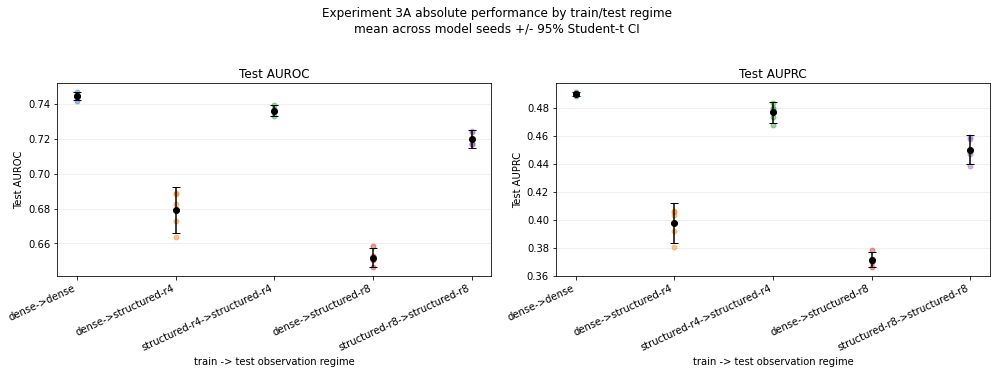

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_exp3a_absolute_performance_ci95.png


In [6]:
def complete_seed_set_for_group(group, seed_col="model_seed"):
    observed = set(group[seed_col].dropna().astype(int).tolist())
    return observed == EXP3_EXPECTED_MODEL_SEEDS


def complete_seed_groups(df, group_cols, seed_col="model_seed"):
    if df is None or len(df) == 0:
        return df
    if EXP3_ALLOW_PARTIAL_RESULTS:
        print("Using partial exploratory results because EXP3_ALLOW_PARTIAL_RESULTS=True.")
        return df.copy()
    keep = []
    for keys, group in df.groupby(list(group_cols)):
        observed = set(group[seed_col].astype(int).tolist())
        if observed == EXP3_EXPECTED_MODEL_SEEDS:
            keep.append(group)
        else:
            print("Incomplete seed set {} observed={} missing={} extra={}".format(
                keys, sorted(observed), sorted(EXP3_EXPECTED_MODEL_SEEDS - observed),
                sorted(observed - EXP3_EXPECTED_MODEL_SEEDS)))
    if not keep:
        return df.iloc[0:0].copy()
    return pd.concat(keep, ignore_index=True)


absolute_group_cols = ["experiment", "horizon", "target_r", "condition", "normalizer_regime"]
exp3_absolute_summary_parts = []
for metric_col in ["test_auroc", "test_auprc", "test_brier"]:
    if len(exp3_run_results):
        metric_summary = summarize_with_t_ci(exp3_run_results, absolute_group_cols, metric_col)
        metric_summary.insert(len(absolute_group_cols), "metric", metric_col)
        exp3_absolute_summary_parts.append(metric_summary)
exp3_absolute_summary = pd.concat(exp3_absolute_summary_parts, ignore_index=True) if exp3_absolute_summary_parts else pd.DataFrame()
show_table("Experiment 3 absolute test performance mean +/- 95% Student-t CI", exp3_absolute_summary, max_rows=300)



def _exp3a_absolute_panel(ax, plot_rows, metric_col, ylabel):
    summary = summarize_with_t_ci(plot_rows, ["condition"], metric_col)
    order = ["dense->dense", "dense->structured-r4", "structured-r4->structured-r4",
             "dense->structured-r8", "structured-r8->structured-r8"]
    summary["order"] = summary["condition"].apply(lambda x: order.index(x) if x in order else 999)
    summary = summary.sort_values("order")
    x = np.arange(len(summary))
    y = summary["mean"].values
    yerr = summary["ci95"].fillna(0.0).values
    ax.errorbar(x, y, yerr=yerr, fmt="o", linestyle="none", capsize=4, color="black")
    for i, condition in enumerate(summary["condition"].tolist()):
        raw = plot_rows[plot_rows["condition"] == condition]
        ax.scatter(np.repeat(i, len(raw)), raw[metric_col].values, alpha=0.45, s=24)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["condition"].tolist(), rotation=25, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("train -> test observation regime")
    ax.set_title(ylabel)
    ax.grid(axis="y", alpha=0.25)


def plot_exp3a_absolute_performance():
    output_name = "experiment3_exp3a_absolute_performance_ci95.png"
    if len(exp3_run_results) == 0:
        print("Skipping {}: no exact prediction rows.".format(output_name))
        return
    plot_rows = exp3_run_results[exp3_run_results["experiment"] == "Exp3A Structured frequency shift"]
    if len(plot_rows) == 0:
        print("Skipping {}: no Exp3A rows.".format(output_name))
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharey=False)
    _exp3a_absolute_panel(axes[0], plot_rows, "test_auroc", "Test AUROC")
    _exp3a_absolute_panel(axes[1], plot_rows, "test_auprc", "Test AUPRC")
    fig.suptitle("Experiment 3A absolute performance by train/test regime\nmean across model seeds +/- 95% Student-t CI", y=1.03)
    fig.tight_layout()
    output_path = EXP3_OUTPUT_DIR / output_name
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


plot_exp3a_absolute_performance()



## Exp3A. Structured Frequency Shift

Does training under the same structured sparse observation regime used at deployment recover performance relative to a dense-trained model evaluated on the identical sparse observations?

The information-effect analysis is descriptive: `M(dense->dense) - M(structured-r->structured-r)`. It is not treated as an additive causal decomposition with the shift effect.

In [7]:
def find_result_row(experiment, horizon, r, condition, normalizer_regime, seed):
    if len(exp3_run_results) == 0:
        return None
    sub = exp3_run_results[
        (exp3_run_results["experiment"] == experiment) &
        (exp3_run_results["horizon"].astype(int) == int(horizon)) &
        (exp3_run_results["target_r"].astype(int) == int(r)) &
        (exp3_run_results["condition"] == condition) &
        (exp3_run_results["normalizer_regime"] == normalizer_regime) &
        (exp3_run_results["model_seed"].astype(int) == int(seed))
    ]
    if len(sub) == 0:
        return None
    if len(sub) > 1:
        raise RuntimeError("Multiple rows for {}, h={}, r={}, condition={}, norm={}, seed={}".format(
            experiment, horizon, r, condition, normalizer_regime, seed))
    return sub.iloc[0]


information_rows = []
for r in EXP3_STRUCTURED_CONFIGS.get(12, []):
    for seed in sorted(EXP3_EXPECTED_MODEL_SEEDS):
        dense = find_result_row("Exp3A Structured frequency shift", 12, 1, "dense->dense", "train_matched", seed)
        sparse = find_result_row("Exp3A Structured frequency shift", 12, r,
                                 "structured-r{}->structured-r{}".format(r, r), "train_matched", seed)
        if dense is None or sparse is None:
            continue
        for metric in EXP3_METRICS:
            col = "test_{}".format(metric)
            left_value = dense[col]
            right_value = sparse[col]
            information_rows.append({
                "experiment": "Exp3A Structured frequency shift",
                "horizon": 12,
                "r": r,
                "model_seed": seed,
                "metric": metric,
                "left_condition": "dense->dense",
                "right_condition": "structured-r{}->structured-r{}".format(r, r),
                "left_metric": left_value,
                "right_metric": right_value,
                "difference": metric_difference(left_value, right_value, metric),
                "interpretation": "descriptive information effect, not additive decomposition",
            })
exp3_information_effects = pd.DataFrame(information_rows)
show_table("Experiment 3A seed-level descriptive information effects", exp3_information_effects, max_rows=200)

if len(exp3_information_effects):
    exp3_information_summary = summarize_with_t_ci(exp3_information_effects, ["experiment", "horizon", "r", "metric"], "difference")
else:
    exp3_information_summary = pd.DataFrame()
show_table("Experiment 3A descriptive information-effect summary", exp3_information_summary, max_rows=100)


Experiment 3A seed-level descriptive information effects


,difference,experiment,horizon,interpretation,left_condition,left_metric,metric,model_seed,r,right_condition,right_metric
0,0.011593,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.746718,auroc,0,4,structured-r4->structured-r4,0.735125
1,0.011939,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.491179,auprc,0,4,structured-r4->structured-r4,0.479240
2,0.002774,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.162099,brier,0,4,structured-r4->structured-r4,0.164873
3,0.008999,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.741809,auroc,1,4,structured-r4->structured-r4,0.732810
4,0.017420,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.490433,auprc,1,4,structured-r4->structured-r4,0.473013
5,0.001591,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.163353,brier,1,4,structured-r4->structured-r4,0.164944
6,0.005797,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.744989,auroc,2,4,structured-r4->structured-r4,0.739192
7,0.006429,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.489568,auprc,2,4,structured-r4->structured-r4,0.483138
8,0.000415,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.163298,brier,2,4,structured-r4->structured-r4,0.163713
9,0.007613,Exp3A Structured frequency shift,12,"descriptive information effect, not additive d...",dense->dense,0.744828,auroc,3,4,structured-r4->structured-r4,0.737215



Experiment 3A descriptive information-effect summary


,ci95,ci95_high,ci95_low,experiment,horizon,mean,metric,n,r,sd,sem
0,0.007871,0.021074,0.005332,Exp3A Structured frequency shift,12,0.013203,auprc,5,4,0.006339,0.002835
1,0.002693,0.010981,0.005595,Exp3A Structured frequency shift,12,0.008288,auroc,5,4,0.002169,0.000970
2,0.001092,0.002805,0.000621,Exp3A Structured frequency shift,12,0.001713,brier,5,4,0.000879,0.000393
3,0.011161,0.050877,0.028556,Exp3A Structured frequency shift,12,0.039716,auprc,5,8,0.008988,0.004020
4,0.005510,0.030040,0.019021,Exp3A Structured frequency shift,12,0.024530,auroc,5,8,0.004437,0.001984
5,0.001405,0.007122,0.004311,Exp3A Structured frequency shift,12,0.005717,brier,5,8,0.001132,0.000506


## Exp3B-D. Controls and Replications

Exp3B asks whether the apparent benefit of sparse-regime training could be explained substantially by using different normalization statistics.

Exp3C asks whether the observation-regime mismatch effect persists when sparsity is random/count-matched rather than caused by periodic structured thinning.

Exp3D asks whether the observation-regime mismatch effect also appears for a substantially longer prediction horizon.

In [8]:
def verify_same_test_examples(left_key, right_key):
    paired = paired_prediction_frame(exp3_predictions[left_key], exp3_predictions[right_key])
    return int(len(paired)), int(paired["patient_id"].nunique())


def contrast_seed(metric, left_row, right_row, contrast_seed_value):
    left_key = prediction_identity(left_row)
    right_key = prediction_identity(right_row)
    paired_n_stays, paired_n_patients = verify_same_test_examples(left_key, right_key)
    result = paired_patient_bootstrap(
        exp3_predictions[left_key],
        exp3_predictions[right_key],
        metric=metric,
        n_boot=EXP3_N_BOOT,
        random_state=contrast_seed_value,
    )
    return result, paired_n_stays, paired_n_patients, left_key, right_key


def compute_seed_level_contrasts(specs):
    rows = []
    for spec in specs:
        for seed in sorted(EXP3_EXPECTED_MODEL_SEEDS):
            left = find_result_row(spec["experiment"], spec["horizon"], spec["r"],
                                   spec["left_condition"], spec["left_normalizer_regime"], seed)
            right = find_result_row(spec["experiment"], spec["horizon"], spec["r"],
                                    spec["right_condition"], spec["right_normalizer_regime"], seed)
            if left is None or right is None:
                continue
            for metric in EXP3_METRICS:
                boot_seed = (EXP3_BOOTSTRAP_SEED + int(spec["horizon"]) * 10000
                             + int(spec["r"]) * 1000 + int(seed) * 10 + EXP3_METRICS.index(metric))
                result, paired_n_stays, paired_n_patients, left_key, right_key = contrast_seed(
                    metric, left, right, boot_seed)
                rows.append({
                    "experiment": spec["experiment"],
                    "contrast": spec["contrast"],
                    "horizon": spec["horizon"],
                    "r": spec["r"],
                    "model_seed": seed,
                    "metric": metric,
                    "left_condition": spec["left_condition"],
                    "right_condition": spec["right_condition"],
                    "left_normalizer_regime": spec["left_normalizer_regime"],
                    "right_normalizer_regime": spec["right_normalizer_regime"],
                    "left_prediction_key": left_key,
                    "right_prediction_key": right_key,
                    "difference": result["difference"],
                    "left_metric": result["left_metric"],
                    "right_metric": result["right_metric"],
                    "patient_bootstrap_ci_low": result["ci_low"],
                    "patient_bootstrap_ci_high": result["ci_high"],
                    "n_patients": result["n_patients"],
                    "n_stays": result["n_stays"],
                    "verified_same_test_examples": True,
                    "verified_same_n_stays": paired_n_stays,
                    "verified_same_n_patients": paired_n_patients,
                    "n_boot_valid": result["n_boot_valid"],
                })
    return pd.DataFrame(rows)


def summarize_contrasts(seed_level_df, prediction_frames=None):
    if prediction_frames is None:
        prediction_frames = exp3_predictions

    summary_rows = []
    if seed_level_df is None or len(seed_level_df) == 0:
        return pd.DataFrame()
    group_cols = ["experiment", "contrast", "horizon", "r", "metric", "left_condition", "right_condition",
                  "left_normalizer_regime", "right_normalizer_regime"]
    for keys, group in seed_level_df.groupby(group_cols):
        (experiment, contrast, horizon, r, metric, left_condition, right_condition,
         left_norm, right_norm) = keys
        seeds = sorted(group["model_seed"].astype(int).unique().tolist())
        complete_seed_set = set(seeds) == EXP3_EXPECTED_MODEL_SEEDS
        if not complete_seed_set:
            print("PARTIAL CONTRAST SEED SET: {} h={} r={} metric={} observed={} missing={} extra={}".format(
                contrast, horizon, r, metric, sorted(seeds),
                sorted(EXP3_EXPECTED_MODEL_SEEDS - set(seeds)), sorted(set(seeds) - EXP3_EXPECTED_MODEL_SEEDS)))
            if not EXP3_ALLOW_PARTIAL_RESULTS:
                print("Skipping final across-seed summary for incomplete contrast because EXP3_ALLOW_PARTIAL_RESULTS=False.")
                continue
        bootstrap_keys = []
        for seed in seeds:
            one = group[group["model_seed"].astype(int) == int(seed)].iloc[0]
            bootstrap_keys.append((seed, one["left_prediction_key"], one["right_prediction_key"]))
        boot = across_seed_patient_bootstrap(
            prediction_frames,
            bootstrap_keys,
            metric=metric,
            n_boot=EXP3_N_BOOT,
            random_state=(EXP3_BOOTSTRAP_SEED + int(horizon) * 10000 + int(r) * 1000 + EXP3_METRICS.index(metric)),
        ) if len(bootstrap_keys) else {
            "patient_bootstrap_ci_low": np.nan,
            "patient_bootstrap_ci_high": np.nan,
        }
        diffs = group["difference"].astype(float).values
        summary_rows.append({
            "experiment": experiment,
            "contrast": contrast,
            "horizon": int(horizon),
            "r": int(r),
            "metric": metric,
            "left_condition": left_condition,
            "right_condition": right_condition,
            "left_normalizer_regime": left_norm,
            "right_normalizer_regime": right_norm,
            "left_mean": float(np.mean(group["left_metric"].astype(float).values)),
            "right_mean": float(np.mean(group["right_metric"].astype(float).values)),
            "mean_difference": float(np.mean(diffs)) if len(diffs) else np.nan,
            "sd_difference": float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan,
            "n_seeds": int(len(seeds)),
            "expected_seeds": int(len(EXP3_EXPECTED_MODEL_SEEDS)),
            "complete_seed_set": complete_seed_set,
            "patient_bootstrap_ci_low": boot["patient_bootstrap_ci_low"],
            "patient_bootstrap_ci_high": boot["patient_bootstrap_ci_high"],
        })
    return pd.DataFrame(summary_rows)


structured_specs = []
for r in EXP3_STRUCTURED_CONFIGS.get(12, []):
    structured_specs.append({
        "experiment": "Exp3A Structured frequency shift",
        "contrast": "structured shift",
        "horizon": 12,
        "r": r,
        "left_condition": "structured-r{}->structured-r{}".format(r, r),
        "right_condition": "dense->structured-r{}".format(r),
        "left_normalizer_regime": "train_matched",
        "right_normalizer_regime": "train_matched",
    })

normalizer_specs = [{
    "experiment": "Exp3B Normalizer control",
    "contrast": "normalizer control",
    "horizon": 12,
    "r": 4,
    "left_condition": "structured-r4 train + train-matched norm",
    "right_condition": "structured-r4 train + dense norm",
    "left_normalizer_regime": "train_matched",
    "right_normalizer_regime": "dense",
}]

random_specs = [{
    "experiment": "Exp3C Random-matched frequency shift",
    "contrast": "random-matched shift",
    "horizon": 12,
    "r": 4,
    "left_condition": "random-r4->random-r4",
    "right_condition": "dense->random-r4",
    "left_normalizer_regime": "train_matched",
    "right_normalizer_regime": "train_matched",
}]

horizon_specs = [{
    "experiment": "Exp3D Horizon replication",
    "contrast": "structured shift",
    "horizon": 96,
    "r": 4,
    "left_condition": "structured-r4->structured-r4",
    "right_condition": "dense->structured-r4",
    "left_normalizer_regime": "train_matched",
    "right_normalizer_regime": "train_matched",
}]

exp3_structured_shift_contrasts = compute_seed_level_contrasts(structured_specs)
exp3_normalizer_control_contrasts = compute_seed_level_contrasts(normalizer_specs)
exp3_random_shift_contrasts = compute_seed_level_contrasts(random_specs)
exp3_horizon_replication_contrasts = compute_seed_level_contrasts(horizon_specs)

show_table("Exp3A. Structured frequency shift seed-level paired-bootstrap contrasts", exp3_structured_shift_contrasts, max_rows=300)
show_table("Exp3B. Normalizer control seed-level paired-bootstrap contrasts", exp3_normalizer_control_contrasts, max_rows=300)
show_table("Exp3C. Random-matched frequency shift seed-level paired-bootstrap contrasts", exp3_random_shift_contrasts, max_rows=300)
show_table("Exp3D. Horizon replication seed-level paired-bootstrap contrasts", exp3_horizon_replication_contrasts, max_rows=300)

exp3_structured_shift_summary = summarize_contrasts(
    exp3_structured_shift_contrasts,
    exp3_predictions,
)

exp3_normalizer_control_summary = summarize_contrasts(
    exp3_normalizer_control_contrasts,
    exp3_predictions,
)

exp3_random_shift_summary = summarize_contrasts(
    exp3_random_shift_contrasts,
    exp3_predictions,
)

exp3_horizon_replication_summary = summarize_contrasts(
    exp3_horizon_replication_contrasts,
    exp3_predictions,
)

show_table("Exp3A. Structured frequency shift across-seed summary", exp3_structured_shift_summary, max_rows=100)
show_table("Exp3B. Normalizer control across-seed summary", exp3_normalizer_control_summary, max_rows=100)
show_table("Exp3C. Random-matched frequency shift across-seed summary", exp3_random_shift_summary, max_rows=100)
show_table("Exp3D. Horizon replication across-seed summary", exp3_horizon_replication_summary, max_rows=100)

# Backward-compatible aliases for the original h=12 structured shift outputs.
exp3_shift_contrasts = exp3_structured_shift_contrasts
exp3_across_seed_summary = exp3_structured_shift_summary
exp3_shift_summary = exp3_structured_shift_summary


Exp3A. Structured frequency shift seed-level paired-bootstrap contrasts


,contrast,difference,experiment,horizon,left_condition,left_metric,left_normalizer_regime,left_prediction_key,metric,model_seed,...,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,right_condition,right_metric,right_normalizer_regime,right_prediction_key,verified_same_n_patients,verified_same_n_stays,verified_same_test_examples
0,structured shift,0.046898,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.735125,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,0,...,0.058386,0.035708,4,dense->structured-r4,0.688227,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
1,structured shift,0.073510,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.479240,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,0,...,0.094838,0.051984,4,dense->structured-r4,0.405730,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
2,structured shift,0.013898,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.164873,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,0,...,0.017156,0.010761,4,dense->structured-r4,0.178771,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
3,structured shift,0.060210,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.732810,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,1,...,0.072821,0.048501,4,dense->structured-r4,0.672600,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
4,structured shift,0.080711,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.473013,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,1,...,0.101197,0.059535,4,dense->structured-r4,0.392302,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
5,structured shift,0.017413,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.164944,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,1,...,0.020764,0.014059,4,dense->structured-r4,0.182358,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
6,structured shift,0.075245,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.739192,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,2,...,0.088194,0.061055,4,dense->structured-r4,0.663947,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
7,structured shift,0.102777,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.483138,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,2,...,0.126935,0.079139,4,dense->structured-r4,0.380361,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
8,structured shift,0.022204,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.163713,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,2,...,0.025784,0.018321,4,dense->structured-r4,0.185917,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True
9,structured shift,0.048541,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.737215,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,3,...,0.059734,0.036592,4,dense->structured-r4,0.688674,train_matched,"(12, none, None, None, structured, 4, None, tr...",5643,6757,True



Exp3B. Normalizer control seed-level paired-bootstrap contrasts


,contrast,difference,experiment,horizon,left_condition,left_metric,left_normalizer_regime,left_prediction_key,metric,model_seed,...,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,right_condition,right_metric,right_normalizer_regime,right_prediction_key,verified_same_n_patients,verified_same_n_stays,verified_same_test_examples
0,normalizer control,-0.000558,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.735125,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,0,...,0.005700,-0.007258,4,structured-r4 train + dense norm,0.735683,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
1,normalizer control,0.003916,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.479240,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,0,...,0.014997,-0.008684,4,structured-r4 train + dense norm,0.475324,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
2,normalizer control,0.000635,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.164873,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,0,...,0.002329,-0.001131,4,structured-r4 train + dense norm,0.165508,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
3,normalizer control,-0.000550,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.732810,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,1,...,0.005892,-0.006909,4,structured-r4 train + dense norm,0.733361,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
4,normalizer control,-0.002525,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.473013,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,1,...,0.007772,-0.012912,4,structured-r4 train + dense norm,0.475538,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
5,normalizer control,0.000232,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.164944,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,1,...,0.001751,-0.001244,4,structured-r4 train + dense norm,0.165176,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
6,normalizer control,0.005286,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.739192,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,2,...,0.011267,-0.000613,4,structured-r4 train + dense norm,0.733905,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
7,normalizer control,0.008851,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.483138,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,2,...,0.020397,-0.003060,4,structured-r4 train + dense norm,0.474287,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
8,normalizer control,0.001691,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.163713,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,2,...,0.003158,0.000284,4,structured-r4 train + dense norm,0.165404,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True
9,normalizer control,0.000050,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.737215,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,3,...,0.006042,-0.005980,4,structured-r4 train + dense norm,0.737166,dense,"(12, structured, 4, None, structured, 4, None,...",5643,6757,True



Exp3C. Random-matched frequency shift seed-level paired-bootstrap contrasts


...

,complete_seed_set,contrast,expected_seeds,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,right_condition,right_mean,right_normalizer_regime,sd_difference
0,True,normalizer control,5,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.476614,train_matched,0.001430,auprc,5,0.006905,-0.004415,4,structured-r4 train + dense norm,0.475184,dense,0.005848
1,True,normalizer control,5,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.736053,train_matched,0.000687,auroc,5,0.004003,-0.002889,4,structured-r4 train + dense norm,0.735366,dense,0.002590
2,True,normalizer control,5,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.164631,train_matched,0.000508,brier,5,0.001370,-0.000435,4,structured-r4 train + dense norm,0.165139,dense,0.000770



Exp3C. Random-matched frequency shift across-seed summary


,complete_seed_set,contrast,expected_seeds,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,right_condition,right_mean,right_normalizer_regime,sd_difference
0,True,random-matched shift,5,Exp3C Random-matched frequency shift,12,random-r4->random-r4,0.444043,train_matched,0.028058,auprc,5,0.041527,0.015692,4,dense->random-r4,0.415985,train_matched,0.006154
1,True,random-matched shift,5,Exp3C Random-matched frequency shift,12,random-r4->random-r4,0.717398,train_matched,0.019363,auroc,5,0.026266,0.012722,4,dense->random-r4,0.698035,train_matched,0.005727
2,True,random-matched shift,5,Exp3C Random-matched frequency shift,12,random-r4->random-r4,0.169695,train_matched,0.005186,brier,5,0.007026,0.003398,4,dense->random-r4,0.174881,train_matched,0.002284



Exp3D. Horizon replication across-seed summary


,complete_seed_set,contrast,expected_seeds,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,right_condition,right_mean,right_normalizer_regime,sd_difference
0,True,structured shift,5,Exp3D Horizon replication,96,structured-r4->structured-r4,0.912325,train_matched,0.010324,auprc,5,0.014934,0.005617,4,dense->structured-r4,0.902001,train_matched,0.002247
1,True,structured shift,5,Exp3D Horizon replication,96,structured-r4->structured-r4,0.735217,train_matched,0.023313,auroc,5,0.031575,0.014630,4,dense->structured-r4,0.711905,train_matched,0.006202
2,True,structured shift,5,Exp3D Horizon replication,96,structured-r4->structured-r4,0.131695,train_matched,0.003955,brier,5,0.005107,0.002692,4,dense->structured-r4,0.135649,train_matched,0.001593


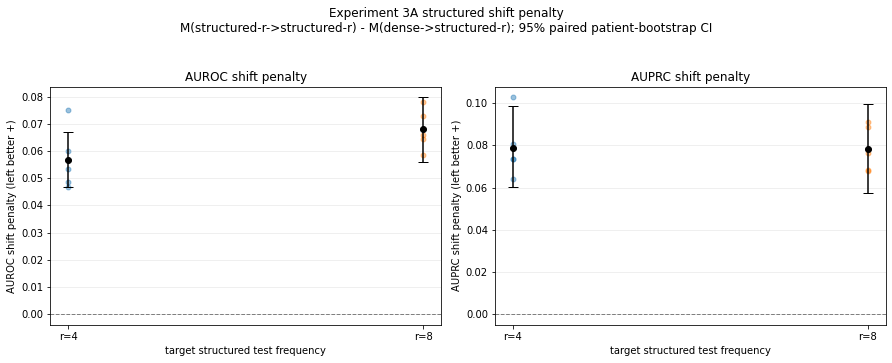

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_exp3a_shift_penalty_bootstrap_ci95.png


In [9]:
def _exp3a_shift_penalty_panel(ax, metric, ylabel):
    sub = exp3_structured_shift_summary[exp3_structured_shift_summary["metric"] == metric].sort_values("r")
    if len(sub) == 0:
        ax.text(0.5, 0.5, "NOT AVAILABLE", transform=ax.transAxes, ha="center", va="center")
        ax.set_axis_off()
        return
    x = np.arange(len(sub))
    y = sub["mean_difference"].values
    lo = sub["patient_bootstrap_ci_low"].values
    hi = sub["patient_bootstrap_ci_high"].values
    yerr = np.nan_to_num(np.vstack([np.maximum(y - lo, 0), np.maximum(hi - y, 0)]), nan=0.0)
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.errorbar(x, y, yerr=yerr, fmt="o", linestyle="none", capsize=5, color="black")
    for i, r in enumerate(sub["r"].tolist()):
        raw = exp3_structured_shift_contrasts[
            (exp3_structured_shift_contrasts["metric"] == metric) &
            (exp3_structured_shift_contrasts["r"].astype(int) == int(r))]
        ax.scatter(np.repeat(i, len(raw)), raw["difference"].values, alpha=0.45, s=24)
    ax.set_xticks(x)
    ax.set_xticklabels(["r={}".format(int(r)) for r in sub["r"].tolist()])
    ax.set_xlabel("target structured test frequency")
    ax.set_ylabel(ylabel)
    ax.set_title("{} shift penalty".format(metric.upper()))
    ax.grid(axis="y", alpha=0.25)


def plot_exp3a_shift_penalties():
    output_name = "experiment3_exp3a_shift_penalty_bootstrap_ci95.png"
    if len(exp3_structured_shift_summary) == 0:
        print("Skipping {}: no structured-shift summaries.".format(output_name))
        return
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=False)
    _exp3a_shift_penalty_panel(axes[0], "auroc", "AUROC shift penalty (left better +)")
    _exp3a_shift_penalty_panel(axes[1], "auprc", "AUPRC shift penalty (left better +)")
    fig.suptitle("Experiment 3A structured shift penalty\nM(structured-r->structured-r) - M(dense->structured-r); 95% paired patient-bootstrap CI", y=1.04)
    fig.tight_layout()
    output_path = EXP3_OUTPUT_DIR / output_name
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


plot_exp3a_shift_penalties()



## Exp3E. Raw-representation frequency shift

This section asks whether the structured train/test frequency mismatch persists when the fixed 1h grid representation is removed. It discovers raw `raw_lstm` runs separately from the existing gridded `lstm` runs, preserves the same validation-AUPRC checkpoint provenance chain, and compares matched raw structured-r training against dense raw training evaluated on the same structured-r raw test regime.

Note: the raw model removes the fixed 1h grid and preserves event order, but it does not currently use explicit timestamps or time-delta features. Exp3E therefore tests whether the frequency-shift effect persists without the fixed grid representation, not whether it persists in a fully time-aware irregular-sequence model.



## Exp3E. Does the frequency-shift effect depend on the grid representation?

Experiments 3A–3D use a fixed 1-hour grid. A possible concern is that the large train/test frequency-mismatch effect observed in Exp3A may partly come from the grid representation itself. For example, changing measurement frequency can change which hourly bins contain observations, the amount of imputation, and the pattern of missingness masks.

Exp3E therefore removes the fixed 1-hour grid and repeats the frequency-shift experiment using a raw event-sequence representation.

The raw model preserves event order but does not currently use explicit timestamps or time-delta features. Therefore, Exp3E tests whether the frequency-shift effect persists without the fixed grid representation; it is not intended as a fully time-aware irregular-sequence model.

### Exp3E-1. Frequency shift in the raw representation

**Question:** Does train/test measurement-frequency mismatch still hurt performance when the fixed 1-hour grid is removed?

For each target measurement interval \(r \in \{4,8\}\) hours, compare two models evaluated on the **same structured-\(r\) raw test data**:

1. **Matched-frequency training**

   $$
   \text{raw structured-}r
   \rightarrow
   \text{raw structured-}r
   $$

2. **Frequency-mismatched training**

   $$
   \text{raw dense}
   \rightarrow
   \text{raw structured-}r
   $$

The raw frequency-shift penalty is

$$
\Delta_{\mathrm{raw}}(r)
=
M(\text{raw structured-}r \rightarrow \text{structured-}r)
-
M(\text{raw dense} \rightarrow \text{structured-}r),
$$

where \(M\) is AUROC, AUPRC, or the sign-oriented Brier metric so that a positive value always indicates an advantage for matched-frequency training.

This comparison holds the **test examples, test measurement regime, and raw representation fixed**. The main difference is whether the model was trained under the same measurement frequency that it sees at test time.

Interpretation:

* \(\Delta_{\mathrm{raw}} > 0\): matched-frequency training performs better, indicating a train/test frequency-shift penalty.
* \(\Delta_{\mathrm{raw}} \approx 0\): little evidence that training-frequency mismatch matters.
* Larger \(\Delta_{\mathrm{raw}}\) at larger \(r\): more severe measurement-frequency reduction produces a larger distribution-shift effect.

Patient-level paired bootstrap is used to estimate uncertainty because both models are evaluated on the same patients.

### Exp3E-2. Does the grid amplify the frequency-shift penalty?

Finding a frequency-shift penalty in the raw model shows that the phenomenon is not solely caused by hourly discretization. We next ask whether the **magnitude** of the mismatch penalty differs between grid and raw representations.

From Exp3A, define the grid-based mismatch penalty:

$$
\Delta_{\mathrm{grid}}(r)
=
M(\text{grid structured-}r \rightarrow \text{structured-}r)
-
M(\text{grid dense} \rightarrow \text{structured-}r).
$$

From Exp3E-1, define:

$$
\Delta_{\mathrm{raw}}(r)
=
M(\text{raw structured-}r \rightarrow \text{structured-}r)
-
M(\text{raw dense} \rightarrow \text{structured-}r).
$$

We then calculate the **difference of shifts**:

$$
\Delta_{\mathrm{grid}}(r)-\Delta_{\mathrm{raw}}(r).
$$

This is the quantity of interest, rather than comparing absolute grid and raw AUROC/AUPRC, because the two representations may have different baseline predictive performance. 

structured-r is raw structured-r + 1hr discretization (fixed hourly sequence)

Does frequency mismatch become worse when sparse measurements are represented through a fixed hourly grid, with hourly binning, imputation, masks, and fixed recurrent steps, compared with representing the retained observations directly as an ordered event sequence?

Interpretation:

* \(\Delta_{\mathrm{grid}}-\Delta_{\mathrm{raw}} > 0\): the frequency-mismatch penalty is larger with the fixed grid.
* \(\Delta_{\mathrm{grid}}-\Delta_{\mathrm{raw}} < 0\): the mismatch penalty is larger with the raw representation.
* \(\Delta_{\mathrm{grid}}-\Delta_{\mathrm{raw}} \approx 0\): both representations have similar sensitivity to frequency mismatch.

For each model seed, all four prediction sets are compared on the same patients:

1. grid matched-frequency model,
2. grid mismatched-frequency model,
3. raw matched-frequency model,
4. raw mismatched-frequency model.

The patient bootstrap resamples patients once per replicate and recomputes all four metrics before calculating

$$
\Delta_{\mathrm{grid}}-\Delta_{\mathrm{raw}}.
$$

This preserves the pairing between the four predictions and directly estimates uncertainty in the difference-of-shifts.

Together, the two analyses answer two separate questions:

* **Exp3E-1:** Is measurement-frequency mismatch itself a real effect even without hourly gridding?
* **Exp3E-2:** Does the fixed grid representation make that mismatch effect larger or smaller?


In [10]:
# ============================================================
# Exp3E: Raw-representation frequency shift
# ============================================================

EXP3_RAW_NETWORK = "mimic4models/keras_models/raw_lstm.py"
EXP3_RAW_HORIZON = 12
EXP3_RAW_RS = [4, 8]
EXP3_RAW_TIMESTEP = 0.0
EXP3_RAW_EXPECTED_CONFIG = dict(EXP3_EXPECTED_CONFIG)
EXP3_RAW_EXPECTED_CONFIG.update({
    "network": EXP3_RAW_NETWORK,
    "timestep": EXP3_RAW_TIMESTEP,
})


def raw_log_dir_for_run_kind(kind, r=None):
    if kind == "raw_dense":
        return EXP3_RESULTS_DIR / "12h" / "keras_logs"
    if kind == "raw_structured":
        return EXP3_RESULTS_DIR / "structured" / "12h" / "{}h".format(int(r)) / "keras_logs"
    raise ValueError("Unknown raw run kind {}".format(kind))


def raw_normalizer_candidates_for_regime(strategy, interval):
    if strategy == "none":
        pattern = "fixed_horizon_icu_exit_raw_ts:0.00_observed_only_n:*.normalizer"
    elif strategy == "structured":
        pattern = "fixed_horizon_icu_exit_raw_sampling:structured_r:{}_ts:0.00_observed_only_n:*.normalizer".format(
            int(interval))
    else:
        raise ValueError("Unknown raw normalizer strategy {}".format(strategy))
    return sorted(EXP3_NORMALIZER_DIR.glob(pattern))


def resolve_raw_normalizer_for_regime(strategy, interval):
    candidates = raw_normalizer_candidates_for_regime(strategy, interval)
    if len(candidates) != 1:
        raise RuntimeError(
            "Expected exactly one raw normalizer for strategy={} interval={} but found {}: {}".format(
                strategy, interval, len(candidates), [str(x) for x in candidates]))
    return candidates[0]


def raw_hyperparameter_mismatch_reason(run):
    reasons = []
    if not run.get("filename", "").startswith("raw_lstm"):
        reasons.append("not a raw_lstm filename")
    for key in ["dim", "depth", "batch_size"]:
        if run.get(key) != EXP3_RAW_EXPECTED_CONFIG[key]:
            reasons.append("{}={} expected {}".format(key, run.get(key), EXP3_RAW_EXPECTED_CONFIG[key]))
    for key in ["dropout", "rec_dropout", "target_repl_coef", "l1", "l2", "timestep"]:
        if _float_mismatch(run.get(key), EXP3_RAW_EXPECTED_CONFIG[key]):
            reasons.append("{}={} expected {}".format(key, run.get(key), EXP3_RAW_EXPECTED_CONFIG[key]))
    if run.get("horizon") != EXP3_RAW_HORIZON:
        reasons.append("horizon={} expected {}".format(run.get("horizon"), EXP3_RAW_HORIZON))
    if bool(run.get("batch_norm")) != bool(EXP3_RAW_EXPECTED_CONFIG["batch_norm"]):
        reasons.append("batch_norm={} expected {}".format(run.get("batch_norm"), EXP3_RAW_EXPECTED_CONFIG["batch_norm"]))
    if run.get("model_seed") not in EXP3_EXPECTED_MODEL_SEEDS:
        reasons.append("model_seed={} not in expected {}".format(run.get("model_seed"), sorted(EXP3_EXPECTED_MODEL_SEEDS)))
    return "; ".join(reasons)


def attach_raw_experiment_config(run):
    run = dict(run)
    for key in EXP3_EXPERIMENT_CONFIG_ASSUMED_FIELDS:
        run[key] = EXP3_RAW_EXPECTED_CONFIG[key]
        run["{}_source".format(key)] = "raw-experiment-config-assumed"
    for key in EXP3_FILENAME_VERIFIED_CONFIG_FIELDS:
        run["{}_source".format(key)] = "filename-verified"
    run["network"] = EXP3_RAW_NETWORK
    run["network_source"] = "raw-experiment-config-assumed"
    run["filename_verified_config_fields"] = ", ".join(EXP3_FILENAME_VERIFIED_CONFIG_FIELDS)
    run["experiment_config_assumed_fields"] = ", ".join(EXP3_EXPERIMENT_CONFIG_ASSUMED_FIELDS)
    run["run_config_artifact_path"] = EXP3_RUN_CONFIG_ARTIFACT_PATH
    run["run_config_artifact_status"] = EXP3_RUN_CONFIG_ARTIFACT_STATUS
    return run


def raw_train_key(strategy, interval, model_seed, kind):
    return (EXP3_RAW_HORIZON, strategy, interval, int(model_seed), kind)


def raw_prediction_identity(row):
    return (
        "raw",
        int(row["horizon"]),
        row["train_sampling_strategy"],
        None if pd.isnull(row["train_sampling_interval"]) else int(row["train_sampling_interval"]),
        None if pd.isnull(row["train_sampling_seed"]) else int(row["train_sampling_seed"]),
        row["test_sampling_strategy"],
        None if pd.isnull(row["test_sampling_interval"]) else int(row["test_sampling_interval"]),
        None if pd.isnull(row["test_sampling_seed"]) else int(row["test_sampling_seed"]),
        row["normalizer_regime"],
        int(row["model_seed"]),
    )


raw_train_status_rows = []
raw_train_excluded_rows = []
raw_train_runs = {}
raw_sources = [{"kind": "raw_dense", "r": None}, *[
    {"kind": "raw_structured", "r": r} for r in EXP3_RAW_RS
]]

for source in raw_sources:
    log_dir = raw_log_dir_for_run_kind(source["kind"], source["r"])
    print("Scanning Exp3E raw logs:", source, log_dir)
    if not log_dir.exists():
        row = dict(source)
        row["exclude_reason"] = "missing log directory"
        row["log_path"] = str(log_dir)
        raw_train_excluded_rows.append(row)
        continue
    for log_path in sorted(log_dir.glob("raw_lstm*.csv")):
        parsed = attach_raw_experiment_config(parse_exp3_log_name(log_path, "raw_train_matched"))
        parsed["run_kind"] = source["kind"]
        parsed["source_r"] = source["r"]
        train_strategy = parsed["train_sampling_strategy"]
        train_interval = parsed["train_sampling_interval"]
        if source["kind"] == "raw_dense":
            is_requested = train_strategy == "none"
        else:
            is_requested = train_strategy == "structured" and train_interval == source["r"]
        if not is_requested:
            row = dict(parsed)
            row["exclude_reason"] = "outside requested Exp3E raw train regimes"
            raw_train_excluded_rows.append(row)
            continue
        mismatch = raw_hyperparameter_mismatch_reason(parsed)
        if mismatch:
            row = dict(parsed)
            row["exclude_reason"] = mismatch
            raw_train_excluded_rows.append(row)
            continue
        val = read_validation_log(log_path, expected_epochs=EXP3_EXPECTED_EPOCHS)
        if val is None:
            row = dict(parsed)
            row["exclude_reason"] = "empty validation log"
            raw_train_excluded_rows.append(row)
            continue
        parsed.update(val)
        parsed["selected_val_epoch"] = parsed["selected_validation_epoch"]
        parsed["selected_val_auprc"] = parsed["validation_auprc"]
        parsed["selected_val_auroc"] = parsed["validation_auroc"]
        checkpoint = find_selected_checkpoint(log_path, parsed["selected_validation_epoch"])
        parsed["checkpoint_path"] = None if checkpoint is None else str(checkpoint)
        parsed["checkpoint_name"] = None if checkpoint is None else checkpoint.name
        normalizer_strategy = "none" if train_strategy == "none" else "structured"
        normalizer_interval = None if train_strategy == "none" else train_interval
        normalizer = resolve_raw_normalizer_for_regime(normalizer_strategy, normalizer_interval)
        parsed["normalizer_path"] = str(normalizer)
        parsed["normalizer_candidates"] = [str(normalizer)]
        raw_train_status_rows.append(dict(parsed))
        if EXP3_REQUIRE_COMPLETE_EPOCHS and not parsed["complete"]:
            row = dict(parsed)
            row["exclude_reason"] = "incomplete epoch set; require exact 0..99"
            raw_train_excluded_rows.append(row)
            continue
        if checkpoint is None:
            row = dict(parsed)
            row["exclude_reason"] = "missing validation-selected checkpoint"
            raw_train_excluded_rows.append(row)
            continue
        key = raw_train_key(train_strategy, train_interval, parsed["model_seed"], source["kind"])
        if key in raw_train_runs:
            raise RuntimeError("Duplicate raw train-run identity {}:\n{}\n{}".format(
                key, raw_train_runs[key]["log_path"], parsed["log_path"]))
        raw_train_runs[key] = parsed

exp3e_raw_train_status = pd.DataFrame(raw_train_status_rows)
exp3e_raw_train_excluded = pd.DataFrame(raw_train_excluded_rows)
show_table("Exp3E raw train-run status", exp3e_raw_train_status, max_rows=300)
show_table("Exp3E excluded/malformed raw train logs", exp3e_raw_train_excluded, max_rows=300)


def get_raw_train_run(strategy, interval, model_seed, kind):
    return raw_train_runs.get(raw_train_key(strategy, interval, model_seed, kind))


def load_raw_prediction_into_row(row, prediction_path, checkpoint):
    parsed_test_strategy, parsed_test_interval, parsed_test_seed, name_mode = parse_prediction_test_regime(
        prediction_path, checkpoint,
        row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"])
    expected_effective = effective_sampling_regime(
        row["test_sampling_strategy"], row["test_sampling_interval"], row["test_sampling_seed"])
    parsed_effective = effective_sampling_regime(parsed_test_strategy, parsed_test_interval, parsed_test_seed)
    if parsed_effective != expected_effective:
        raise RuntimeError("Raw prediction test-regime suffix mismatch for {}: parsed {} expected {}".format(
            prediction_path, parsed_effective, expected_effective))
    pred_df = load_prediction_csv(prediction_path)
    metrics = prediction_metrics(pred_df)
    row.update(metrics)
    row["prediction_path"] = str(prediction_path)
    row["prediction_status"] = "found"
    row["prediction_exists"] = True
    row["prediction_name_mode"] = name_mode
    row["missing_reason"] = None


def add_raw_eval(planned_rows, missing_rows, train_run, test_strategy, test_interval,
                 condition, r, model_seed):
    row = dict(train_run)
    row.update({
        "experiment": "Exp3E Raw-representation frequency shift",
        "test_sampling_strategy": test_strategy,
        "test_sampling_interval": test_interval,
        "test_sampling_seed": None,
        "regime": "raw-{}".format(regime_label(row["train_sampling_strategy"], row["train_sampling_interval"],
                                                 test_strategy, test_interval)),
        "condition": condition,
        "contrast_family": "raw_structured_shift",
        "target_r": r,
    })
    checkpoint = Path(row["checkpoint_path"])
    prediction_path = expected_prediction_path(
        row["output_dir"], checkpoint,
        row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
        test_strategy, test_interval, None,
    )
    row["expected_prediction_path"] = str(prediction_path)
    row["prediction_path"] = None
    row["prediction_status"] = "missing"
    row["prediction_exists"] = prediction_path.exists()
    row["prediction_name_mode"] = None
    row["missing_reason"] = None
    row["suggested_inference_command"] = build_missing_inference_command(row)
    row["prediction_key"] = raw_prediction_identity(row)
    if prediction_path.exists():
        run_test_inference_for_row(row)
        row["prediction_exists"] = prediction_path.exists()
        load_raw_prediction_into_row(row, prediction_path, checkpoint)
    else:
        row["missing_reason"] = "missing exact raw prediction for selected checkpoint/test regime"
        run_test_inference_for_row(row)
        row["prediction_exists"] = prediction_path.exists()
        load_raw_prediction_into_row(row, prediction_path, checkpoint)
    planned_rows.append(row)


def maybe_add_raw_eval(planned_rows, missing_rows, train_strategy, train_interval, kind,
                       test_strategy, test_interval, condition, r, model_seed):
    train_run = get_raw_train_run(train_strategy, train_interval, model_seed, kind)
    if train_run is None:
        missing_rows.append({
            "experiment": "Exp3E Raw-representation frequency shift",
            "horizon": EXP3_RAW_HORIZON,
            "target_r": r,
            "model_seed": model_seed,
            "train_sampling_strategy": train_strategy,
            "train_sampling_interval": train_interval,
            "test_sampling_strategy": test_strategy,
            "test_sampling_interval": test_interval,
            "normalizer_regime": "raw_train_matched",
            "run_kind": kind,
            "condition": condition,
            "missing_reason": "missing eligible raw validation-selected train run",
        })
        return
    add_raw_eval(planned_rows, missing_rows, train_run, test_strategy, test_interval, condition, r, model_seed)


raw_planned_rows = []
raw_missing_rows = []
for seed in sorted(EXP3_EXPECTED_MODEL_SEEDS):
    for r in EXP3_RAW_RS:
        maybe_add_raw_eval(raw_planned_rows, raw_missing_rows,
                           "none", None, "raw_dense",
                           "structured", r, "raw-dense->raw-structured-r{}".format(r), r, seed)
        maybe_add_raw_eval(raw_planned_rows, raw_missing_rows,
                           "structured", r, "raw_structured",
                           "structured", r, "raw-structured-r{}->raw-structured-r{}".format(r, r), r, seed)

exp3e_raw_run_status = pd.DataFrame(raw_planned_rows)
if len(exp3e_raw_run_status):
    exp3e_raw_run_status = exp3e_raw_run_status.sort_values(
        ["target_r", "condition", "model_seed"]
    ).reset_index(drop=True)
exp3e_raw_missing_planned_runs = pd.DataFrame(raw_missing_rows)
raw_missing_mask = exp3e_raw_run_status["prediction_status"] != "found" if len(exp3e_raw_run_status) else []
exp3e_raw_missing_predictions = exp3e_raw_run_status[raw_missing_mask].copy() if len(exp3e_raw_run_status) else pd.DataFrame()
if len(exp3e_raw_missing_planned_runs):
    exp3e_raw_missing_predictions = pd.concat([exp3e_raw_missing_predictions, exp3e_raw_missing_planned_runs], ignore_index=True)
exp3e_raw_run_results = exp3e_raw_run_status[exp3e_raw_run_status["prediction_status"] == "found"].copy() if len(exp3e_raw_run_status) else pd.DataFrame()

exp3e_predictions = {}
exp3e_prediction_paths = {}
if len(exp3e_raw_run_results):
    for _, row in exp3e_raw_run_results.iterrows():
        key = raw_prediction_identity(row)
        pred_path = str(row["prediction_path"])
        pred_df = load_prediction_csv(pred_path)
        if key in exp3e_predictions:
            existing_path = exp3e_prediction_paths[key]
            if existing_path == pred_path:
                continue
            existing = normalized_prediction_identity_frame(exp3e_predictions[key])
            new_prediction = normalized_prediction_identity_frame(pred_df)
            if not existing.equals(new_prediction):
                raise RuntimeError("Duplicate raw prediction identity has different prediction files: {}".format(key))
        else:
            exp3e_predictions[key] = pred_df
            exp3e_prediction_paths[key] = pred_path

raw_status_cols = [
    "target_r", "model_seed", "condition", "train_sampling_strategy", "train_sampling_interval",
    "test_sampling_strategy", "test_sampling_interval", "timestep", "n_epochs", "complete",
    "selected_val_epoch", "selected_val_auprc", "selected_val_auroc", "checkpoint_path",
    "normalizer_path", "expected_prediction_path", "prediction_path", "prediction_status",
    "test_auroc", "test_auprc", "test_brier",
]
show_table("Exp3E raw run-status table", exp3e_raw_run_status[[c for c in raw_status_cols if c in exp3e_raw_run_status.columns]], max_rows=300)
show_table("Exp3E excluded/missing raw runs", exp3e_raw_missing_predictions[[c for c in raw_status_cols + ["missing_reason", "suggested_inference_command"] if c in exp3e_raw_missing_predictions.columns]], max_rows=300)



Scanning Exp3E raw logs: {'kind': 'raw_dense', 'r': None} /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h/keras_logs
Scanning Exp3E raw logs: {'kind': 'raw_structured', 'r': 4} /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured/12h/4h/keras_logs
Scanning Exp3E raw logs: {'kind': 'raw_structured', 'r': 8} /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured/12h/8h/keras_logs

Exp3E raw train-run status


,batch_norm,batch_norm_source,batch_size,batch_size_source,best_csv_epoch,best_val_auprc,best_val_epoch,beta_1,beta_1_source,checkpoint_epoch,...,train_sampling_interval_source,train_sampling_seed,train_sampling_seed_source,train_sampling_strategy,train_sampling_strategy_source,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,False,filename-verified,8,filename-verified,27,0.455557,27,0.9,raw-experiment-config-assumed,28,...,filename-verified,None,filename-verified,none,filename-verified,0.455557,0.709412,0.709412,0.455557,0.709412
1,False,filename-verified,8,filename-verified,64,0.461063,64,0.9,raw-experiment-config-assumed,65,...,filename-verified,None,filename-verified,none,filename-verified,0.461063,0.710525,0.710525,0.461063,0.710525
2,False,filename-verified,8,filename-verified,73,0.456614,73,0.9,raw-experiment-config-assumed,74,...,filename-verified,None,filename-verified,none,filename-verified,0.456614,0.711496,0.711496,0.456614,0.711496
3,False,filename-verified,8,filename-verified,50,0.458326,50,0.9,raw-experiment-config-assumed,51,...,filename-verified,None,filename-verified,none,filename-verified,0.458326,0.709506,0.709506,0.458326,0.709506
4,False,filename-verified,8,filename-verified,71,0.456792,71,0.9,raw-experiment-config-assumed,72,...,filename-verified,None,filename-verified,none,filename-verified,0.456792,0.710947,0.710947,0.456792,0.710947
5,False,filename-verified,8,filename-verified,91,0.436104,91,0.9,raw-experiment-config-assumed,92,...,filename-verified,None,filename-verified,structured,filename-verified,0.436104,0.699120,0.699120,0.436104,0.699120
6,False,filename-verified,8,filename-verified,90,0.439043,90,0.9,raw-experiment-config-assumed,91,...,filename-verified,None,filename-verified,structured,filename-verified,0.439043,0.697495,0.697495,0.439043,0.697495
7,False,filename-verified,8,filename-verified,53,0.431025,53,0.9,raw-experiment-config-assumed,54,...,filename-verified,None,filename-verified,structured,filename-verified,0.431025,0.694229,0.694229,0.431025,0.694229
8,False,filename-verified,8,filename-verified,83,0.437201,83,0.9,raw-experiment-config-assumed,84,...,filename-verified,None,filename-verified,structured,filename-verified,0.437201,0.695302,0.695302,0.437201,0.695302
9,False,filename-verified,8,filename-verified,37,0.432701,37,0.9,raw-experiment-config-assumed,38,...,filename-verified,None,filename-verified,structured,filename-verified,0.432701,0.696261,0.696261,0.432701,0.696261



Exp3E excluded/malformed raw train logs
<none>
Missing test prediction; running inference:
/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h/test_predictions/raw_lstm.n16.d0.3.dep2.h12.bs8.ts0.0.seed4.epoch72.test0.5197017968529568.state.testsample-structured-r4.csv
  experiment/subexperiment: Exp3E Raw-representation frequency shift
  horizon: 12
  model seed: 4
  train sampling regime: ('none',)
  test sampling regime: ('structured', 4)
  normalizer regime/path: raw_train_matched /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/normalizers/fixed_horizon_icu_exit_raw_ts:0.00_observed_only_n:21860.normalizer
  selected epoch: 71
  checkpoint: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h/keras_states/raw_lstm.n16.d0.3.dep2.h12.bs8.ts0.0.seed4.epoch72.test0.5197017968529568.state
  exact 

,target_r,model_seed,condition,train_sampling_strategy,train_sampling_interval,test_sampling_strategy,test_sampling_interval,timestep,n_epochs,complete,...,selected_val_auprc,selected_val_auroc,checkpoint_path,normalizer_path,expected_prediction_path,prediction_path,prediction_status,test_auroc,test_auprc,test_brier
0,4,0,raw-dense->raw-structured-r4,none,NaN,structured,4,0.0,100,True,...,0.455557,0.709412,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.670456,0.394753,0.178448
1,4,1,raw-dense->raw-structured-r4,none,NaN,structured,4,0.0,100,True,...,0.461063,0.710525,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.669296,0.394689,0.178894
2,4,2,raw-dense->raw-structured-r4,none,NaN,structured,4,0.0,100,True,...,0.456614,0.711496,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.666083,0.396214,0.179954
3,4,3,raw-dense->raw-structured-r4,none,NaN,structured,4,0.0,100,True,...,0.458326,0.709506,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.666479,0.397208,0.177996
4,4,4,raw-dense->raw-structured-r4,none,NaN,structured,4,0.0,100,True,...,0.456792,0.710947,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.669640,0.396064,0.178409
5,4,0,raw-structured-r4->raw-structured-r4,structured,4.0,structured,4,0.0,100,True,...,0.436104,0.699120,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.708797,0.445442,0.169766
6,4,1,raw-structured-r4->raw-structured-r4,structured,4.0,structured,4,0.0,100,True,...,0.439043,0.697495,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.713743,0.452897,0.168922
7,4,2,raw-structured-r4->raw-structured-r4,structured,4.0,structured,4,0.0,100,True,...,0.431025,0.694229,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.709321,0.444933,0.169515
8,4,3,raw-structured-r4->raw-structured-r4,structured,4.0,structured,4,0.0,100,True,...,0.437201,0.695302,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.709112,0.440468,0.170003
9,4,4,raw-structured-r4->raw-structured-r4,structured,4.0,structured,4,0.0,100,True,...,0.432701,0.696261,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,found,0.710284,0.443751,0.169831



Exp3E excluded/missing raw runs
<none>


### Raw representation sequence-length statistics

Raw sequence length is the number of raw temporal steps/events supplied to the raw representation before 1h gridding. It can vary across stays. Structured thinning may reduce the raw sequence length because observations are removed. These statistics characterize the raw data representation and are not model-specific, so they are computed once here and should not be duplicated for GRU-D.


In [11]:
# ============================================================
# Exp3E raw representation sequence-length characterization
# ============================================================


def build_exp3e_raw_reader(condition, r=None):
    dataset_dir = EXP3_DATA_DIR / "test"
    listfile = EXP3_DATA_DIR / "test_listfile.csv"
    reader = FixedHorizonIcuExitReader(
        dataset_dir=str(dataset_dir),
        listfile=str(listfile),
        horizon=EXP3_RAW_HORIZON,
    )
    if condition == "dense/raw":
        return reader
    if condition in ["structured-r4/raw", "structured-r8/raw"]:
        return SamplingReader(reader, strategy="structured", sampling_interval=int(r), sampling_seed=None)
    raise ValueError("Unknown raw sequence-length condition {}".format(condition))


def raw_sequence_lengths_for_reader(reader, encoder):
    lengths = []
    n_examples = reader.get_number_of_examples()
    for index in range(n_examples):
        example = reader.read_example(index)
        encoded, _ = encoder.transform(example["X"], header=example["header"], end=example["t"])
        lengths.append(int(encoded.shape[0]))
    return np.asarray(lengths, dtype=float)


def summarize_raw_sequence_lengths(condition, r=None):
    reader = build_exp3e_raw_reader(condition, r=r)
    lengths = raw_sequence_lengths_for_reader(reader, RawSequenceEncoder())
    if len(lengths) == 0:
        return {
            "condition": condition,
            "r": r,
            "n_stays": 0,
            "mean_sequence_length": np.nan,
            "median_sequence_length": np.nan,
            "p25_sequence_length": np.nan,
            "p75_sequence_length": np.nan,
            "p95_sequence_length": np.nan,
            "min_sequence_length": np.nan,
            "max_sequence_length": np.nan,
        }
    return {
        "condition": condition,
        "r": r,
        "n_stays": int(len(lengths)),
        "mean_sequence_length": float(np.mean(lengths)),
        "median_sequence_length": float(np.percentile(lengths, 50)),
        "p25_sequence_length": float(np.percentile(lengths, 25)),
        "p75_sequence_length": float(np.percentile(lengths, 75)),
        "p95_sequence_length": float(np.percentile(lengths, 95)),
        "min_sequence_length": int(np.min(lengths)),
        "max_sequence_length": int(np.max(lengths)),
    }


exp3e_raw_sequence_length_summary = pd.DataFrame([
    summarize_raw_sequence_lengths("dense/raw", r=np.nan),
    summarize_raw_sequence_lengths("structured-r4/raw", r=4),
    summarize_raw_sequence_lengths("structured-r8/raw", r=8),
])
exp3e_raw_sequence_length_cols = [
    "condition", "r", "n_stays", "mean_sequence_length", "median_sequence_length",
    "p25_sequence_length", "p75_sequence_length", "p95_sequence_length",
    "min_sequence_length", "max_sequence_length",
]
exp3e_raw_sequence_length_summary = exp3e_raw_sequence_length_summary[exp3e_raw_sequence_length_cols]
show_table("Exp3E raw representation sequence-length statistics", exp3e_raw_sequence_length_summary, max_rows=20)



Exp3E raw representation sequence-length statistics


,condition,r,n_stays,mean_sequence_length,median_sequence_length,p25_sequence_length,p75_sequence_length,p95_sequence_length,min_sequence_length,max_sequence_length
0,dense/raw,NaN,6757,18.851709,7.0,3.0,37.0,59.0,1,194
1,structured-r4/raw,4.0,6757,9.028119,5.0,3.0,16.0,24.0,1,36
2,structured-r8/raw,8.0,6757,5.983869,4.0,2.0,10.0,15.0,1,21


In [12]:
# ============================================================
# Exp3E raw shift contrasts and grid-vs-raw difference of shifts
# ============================================================


def find_raw_result_row(r, condition, seed):
    if len(exp3e_raw_run_results) == 0:
        return None
    sub = exp3e_raw_run_results[
        (exp3e_raw_run_results["target_r"].astype(int) == int(r)) &
        (exp3e_raw_run_results["condition"] == condition) &
        (exp3e_raw_run_results["model_seed"].astype(int) == int(seed))
    ]
    if len(sub) == 0:
        return None
    if len(sub) > 1:
        raise RuntimeError("Multiple raw rows for r={} condition={} seed={}".format(r, condition, seed))
    return sub.iloc[0]


def raw_contrast_seed(metric, left_row, right_row, contrast_seed_value):
    left_key = raw_prediction_identity(left_row)
    right_key = raw_prediction_identity(right_row)
    paired = paired_prediction_frame(exp3e_predictions[left_key], exp3e_predictions[right_key])
    result = paired_patient_bootstrap(
        exp3e_predictions[left_key],
        exp3e_predictions[right_key],
        metric=metric,
        n_boot=EXP3_N_BOOT,
        random_state=contrast_seed_value,
    )
    return result, int(len(paired)), int(paired["patient_id"].nunique()), left_key, right_key


raw_contrast_rows = []
for r in EXP3_RAW_RS:
    left_condition = "raw-structured-r{}->raw-structured-r{}".format(r, r)
    right_condition = "raw-dense->raw-structured-r{}".format(r)
    for seed in sorted(EXP3_EXPECTED_MODEL_SEEDS):
        left = find_raw_result_row(r, left_condition, seed)
        right = find_raw_result_row(r, right_condition, seed)
        if left is None or right is None:
            continue
        for metric in EXP3_METRICS:
            boot_seed = EXP3_BOOTSTRAP_SEED + 900000 + int(r) * 1000 + int(seed) * 10 + EXP3_METRICS.index(metric)
            result, paired_n_stays, paired_n_patients, left_key, right_key = raw_contrast_seed(
                metric, left, right, boot_seed)
            raw_contrast_rows.append({
                "experiment": "Exp3E Raw-representation frequency shift",
                "contrast": "raw structured shift",
                "horizon": EXP3_RAW_HORIZON,
                "r": r,
                "model_seed": seed,
                "metric": metric,
                "left_condition": left_condition,
                "right_condition": right_condition,
                "left_normalizer_regime": "raw_train_matched",
                "right_normalizer_regime": "raw_train_matched",
                "left_prediction_key": left_key,
                "right_prediction_key": right_key,
                "left_metric": result["left_metric"],
                "right_metric": result["right_metric"],
                "difference": result["difference"],
                "patient_bootstrap_ci_low": result["ci_low"],
                "patient_bootstrap_ci_high": result["ci_high"],
                "n_patients": result["n_patients"],
                "n_stays": result["n_stays"],
                "verified_same_test_examples": True,
                "verified_same_n_stays": paired_n_stays,
                "verified_same_n_patients": paired_n_patients,
                "n_boot_valid": result["n_boot_valid"],
            })
exp3e_raw_shift_contrasts = pd.DataFrame(raw_contrast_rows)
show_table("Exp3E raw shift seed-level contrasts", exp3e_raw_shift_contrasts, max_rows=300)
exp3e_raw_shift_summary = summarize_contrasts(
    exp3e_raw_shift_contrasts,
    exp3e_predictions,
)
show_table("Exp3E. Raw-representation frequency shift across-seed summary", exp3e_raw_shift_summary, max_rows=100)


def merge_four_prediction_frames(grid_matched_df, grid_mismatched_df, raw_matched_df, raw_mismatched_df):
    frames = [
        ("grid_matched", grid_matched_df),
        ("grid_mismatched", grid_mismatched_df),
        ("raw_matched", raw_matched_df),
        ("raw_mismatched", raw_mismatched_df),
    ]
    merged = None
    base_cols = ["stay", "patient_id", "y_true"]
    for label, df in frames:
        duplicate_stays = df[df["stay"].duplicated()]["stay"].astype(str).unique().tolist()
        if len(duplicate_stays):
            raise ValueError(
                "Four-model paired comparison found duplicate stay IDs in {}: {}".format(
                    label, duplicate_stays[:10]))
        sub = df[base_cols + ["prediction"]].rename(columns={"prediction": "pred_{}".format(label)})
        if merged is None:
            merged = sub
        else:
            merged = merged.merge(sub, on=base_cols, how="inner")
    expected_n = len(grid_matched_df)
    if len(merged) != expected_n or any(len(df) != expected_n for _, df in frames):
        raise ValueError("Four-model paired comparison has different stay sets: merged={} expected={}".format(
            len(merged), expected_n))
    return merged.reset_index(drop=True)


def four_model_shift_values(paired, metric, indices=None):
    if indices is None:
        indices = np.arange(len(paired))
    y = paired["y_true"].values[indices]
    grid_matched = compute_metric(y, paired["pred_grid_matched"].values[indices], metric)
    grid_mismatched = compute_metric(y, paired["pred_grid_mismatched"].values[indices], metric)
    raw_matched = compute_metric(y, paired["pred_raw_matched"].values[indices], metric)
    raw_mismatched = compute_metric(y, paired["pred_raw_mismatched"].values[indices], metric)
    grid_shift = metric_difference(grid_matched, grid_mismatched, metric)
    raw_shift = metric_difference(raw_matched, raw_mismatched, metric)
    return grid_shift, raw_shift, grid_shift - raw_shift


def four_model_patient_bootstrap(grid_matched_df, grid_mismatched_df, raw_matched_df, raw_mismatched_df,
                                 metric, n_boot=2000, random_state=DEFAULT_BOOTSTRAP_SEED):
    paired = merge_four_prediction_frames(grid_matched_df, grid_mismatched_df, raw_matched_df, raw_mismatched_df)
    point_grid, point_raw, point_diff = four_model_shift_values(paired, metric)
    rng = np.random.RandomState(random_state)
    patient_ids = np.asarray(sorted(paired["patient_id"].unique()))
    patient_to_indices = {
        pid: np.where(paired["patient_id"].values == pid)[0]
        for pid in patient_ids
    }
    boot_diffs = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        sampled_indices = np.concatenate([patient_to_indices[pid] for pid in sampled_patients])
        _, _, diff = four_model_shift_values(paired, metric, sampled_indices)
        if not np.isnan(diff):
            boot_diffs.append(diff)
    boot_diffs = np.asarray(boot_diffs)
    if len(boot_diffs):
        ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    else:
        ci_low, ci_high = np.nan, np.nan
    return {
        "grid_shift": point_grid,
        "raw_shift": point_raw,
        "grid_minus_raw_shift": point_diff,
        "ci_low": float(ci_low) if not np.isnan(ci_low) else np.nan,
        "ci_high": float(ci_high) if not np.isnan(ci_high) else np.nan,
        "n_patients": int(len(patient_ids)),
        "n_stays": int(len(paired)),
        "n_boot_valid": int(len(boot_diffs)),
        "boot_diffs": boot_diffs,
    }


def across_seed_four_model_bootstrap(records, metric, n_boot=2000, random_state=DEFAULT_BOOTSTRAP_SEED):
    paired_by_seed = {}
    first_patients = None
    point_rows = []
    for record in records:
        seed = int(record["seed"])
        paired = merge_four_prediction_frames(
            record["grid_matched_df"], record["grid_mismatched_df"],
            record["raw_matched_df"], record["raw_mismatched_df"])
        patients = np.asarray(sorted(paired["patient_id"].unique()))
        if first_patients is None:
            first_patients = patients
        elif not np.array_equal(first_patients, patients):
            raise ValueError("Patient sets differ across seeds for four-model bootstrap metric {}".format(metric))
        grid_shift, raw_shift, diff = four_model_shift_values(paired, metric)
        point_rows.append((grid_shift, raw_shift, diff))
        paired_by_seed[seed] = paired
    if first_patients is None:
        return {"patient_bootstrap_ci_low": np.nan, "patient_bootstrap_ci_high": np.nan}
    rng = np.random.RandomState(random_state)
    patient_ids = first_patients
    patient_to_indices = {
        seed: {pid: np.where(paired["patient_id"].values == pid)[0] for pid in patient_ids}
        for seed, paired in paired_by_seed.items()
    }
    boot_means = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        seed_diffs = []
        for seed, paired in paired_by_seed.items():
            sampled_indices = np.concatenate([patient_to_indices[seed][pid] for pid in sampled_patients])
            _, _, diff = four_model_shift_values(paired, metric, sampled_indices)
            if not np.isnan(diff):
                seed_diffs.append(diff)
        if len(seed_diffs):
            boot_means.append(float(np.mean(seed_diffs)))
    boot_means = np.asarray(boot_means)
    if len(boot_means):
        ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    else:
        ci_low, ci_high = np.nan, np.nan
    point_rows = np.asarray(point_rows)
    return {
        "mean_grid_shift": float(np.mean(point_rows[:, 0])),
        "mean_raw_shift": float(np.mean(point_rows[:, 1])),
        "mean_grid_minus_raw_shift": float(np.mean(point_rows[:, 2])),
        "patient_bootstrap_ci_low": float(ci_low) if not np.isnan(ci_low) else np.nan,
        "patient_bootstrap_ci_high": float(ci_high) if not np.isnan(ci_high) else np.nan,
        "boot_diffs": boot_means,
    }


grid_raw_rows = []
grid_raw_bootstrap_records = []
for r in EXP3_RAW_RS:
    for seed in sorted(EXP3_EXPECTED_MODEL_SEEDS):
        grid_matched = find_result_row("Exp3A Structured frequency shift", 12, r,
                                       "structured-r{}->structured-r{}".format(r, r), "train_matched", seed)
        grid_mismatched = find_result_row("Exp3A Structured frequency shift", 12, r,
                                          "dense->structured-r{}".format(r), "train_matched", seed)
        raw_matched = find_raw_result_row(r, "raw-structured-r{}->raw-structured-r{}".format(r, r), seed)
        raw_mismatched = find_raw_result_row(r, "raw-dense->raw-structured-r{}".format(r), seed)
        if any(x is None for x in [grid_matched, grid_mismatched, raw_matched, raw_mismatched]):
            continue
        grid_matched_key = prediction_identity(grid_matched)
        grid_mismatched_key = prediction_identity(grid_mismatched)
        raw_matched_key = raw_prediction_identity(raw_matched)
        raw_mismatched_key = raw_prediction_identity(raw_mismatched)
        record = {
            "r": r,
            "seed": seed,
            "grid_matched_df": exp3_predictions[grid_matched_key],
            "grid_mismatched_df": exp3_predictions[grid_mismatched_key],
            "raw_matched_df": exp3e_predictions[raw_matched_key],
            "raw_mismatched_df": exp3e_predictions[raw_mismatched_key],
        }
        for metric in EXP3_METRICS:
            boot_seed = EXP3_BOOTSTRAP_SEED + 950000 + int(r) * 1000 + int(seed) * 10 + EXP3_METRICS.index(metric)
            boot = four_model_patient_bootstrap(
                record["grid_matched_df"], record["grid_mismatched_df"],
                record["raw_matched_df"], record["raw_mismatched_df"],
                metric=metric, n_boot=EXP3_N_BOOT, random_state=boot_seed)
            grid_raw_rows.append({
                "r": r,
                "model_seed": seed,
                "seed": seed,
                "metric": metric,
                "grid_shift": boot["grid_shift"],
                "raw_shift": boot["raw_shift"],
                "grid_minus_raw_shift": boot["grid_minus_raw_shift"],
                "bootstrap_ci_low": boot["ci_low"],
                "bootstrap_ci_high": boot["ci_high"],
                "n_patients": boot["n_patients"],
                "n_stays": boot["n_stays"],
                "n_boot_valid": boot["n_boot_valid"],
            })
            rec = dict(record)
            rec["metric"] = metric
            grid_raw_bootstrap_records.append(rec)

exp3_grid_vs_raw_shift_contrasts = pd.DataFrame(grid_raw_rows)
show_table("Grid vs raw representation seed-level difference-of-shifts", exp3_grid_vs_raw_shift_contrasts, max_rows=300)

summary_rows = []
if len(exp3_grid_vs_raw_shift_contrasts):
    for (r, metric), group in exp3_grid_vs_raw_shift_contrasts.groupby(["r", "metric"]):
        seeds = sorted(group["model_seed"].astype(int).unique().tolist())
        complete_seed_set = set(seeds) == EXP3_EXPECTED_MODEL_SEEDS
        if not complete_seed_set:
            print("PARTIAL GRID-VS-RAW SEED SET: r={} metric={} observed={} missing={} extra={}".format(
                r, metric, sorted(seeds), sorted(EXP3_EXPECTED_MODEL_SEEDS - set(seeds)),
                sorted(set(seeds) - EXP3_EXPECTED_MODEL_SEEDS)))
            if not EXP3_ALLOW_PARTIAL_RESULTS:
                print("Skipping final grid-vs-raw summary for incomplete contrast because EXP3_ALLOW_PARTIAL_RESULTS=False.")
                continue
        records = [rec for rec in grid_raw_bootstrap_records if int(rec["r"]) == int(r) and rec["metric"] == metric]
        boot = across_seed_four_model_bootstrap(
            records, metric=metric, n_boot=EXP3_N_BOOT,
            random_state=EXP3_BOOTSTRAP_SEED + 960000 + int(r) * 1000 + EXP3_METRICS.index(metric))
        diffs = group["grid_minus_raw_shift"].astype(float).values
        summary_rows.append({
            "r": int(r),
            "metric": metric,
            "mean_grid_shift": boot["mean_grid_shift"],
            "mean_raw_shift": boot["mean_raw_shift"],
            "mean_grid_minus_raw_shift": boot["mean_grid_minus_raw_shift"],
            "sd_grid_minus_raw_shift": float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan,
            "n_seeds": int(len(seeds)),
            "expected_seeds": int(len(EXP3_EXPECTED_MODEL_SEEDS)),
            "complete_seed_set": complete_seed_set,
            "patient_bootstrap_ci_low": boot["patient_bootstrap_ci_low"],
            "patient_bootstrap_ci_high": boot["patient_bootstrap_ci_high"],
        })
exp3_grid_vs_raw_shift_summary = pd.DataFrame(summary_rows)
show_table("Grid vs raw representation across-seed difference-of-shifts summary", exp3_grid_vs_raw_shift_summary, max_rows=100)





Exp3E raw shift seed-level contrasts


,contrast,difference,experiment,horizon,left_condition,left_metric,left_normalizer_regime,left_prediction_key,metric,model_seed,...,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,right_condition,right_metric,right_normalizer_regime,right_prediction_key,verified_same_n_patients,verified_same_n_stays,verified_same_test_examples
0,raw structured shift,0.038340,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.708797,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",auroc,0,...,0.049526,0.027425,4,raw-dense->raw-structured-r4,0.670456,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
1,raw structured shift,0.050689,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.445442,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",auprc,0,...,0.070940,0.030353,4,raw-dense->raw-structured-r4,0.394753,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
2,raw structured shift,0.008682,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.169766,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",brier,0,...,0.011445,0.006051,4,raw-dense->raw-structured-r4,0.178448,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
3,raw structured shift,0.044447,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.713743,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",auroc,1,...,0.054986,0.034193,4,raw-dense->raw-structured-r4,0.669296,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
4,raw structured shift,0.058208,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.452897,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",auprc,1,...,0.075696,0.040502,4,raw-dense->raw-structured-r4,0.394689,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
5,raw structured shift,0.009972,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.168922,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",brier,1,...,0.012861,0.007198,4,raw-dense->raw-structured-r4,0.178894,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
6,raw structured shift,0.043238,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.709321,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",auroc,2,...,0.053501,0.032293,4,raw-dense->raw-structured-r4,0.666083,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
7,raw structured shift,0.048719,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.444933,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",auprc,2,...,0.065188,0.029516,4,raw-dense->raw-structured-r4,0.396214,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
8,raw structured shift,0.010439,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.169515,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",brier,2,...,0.013057,0.007991,4,raw-dense->raw-structured-r4,0.179954,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True
9,raw structured shift,0.042633,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.709112,raw_train_matched,"(raw, 12, structured, 4, None, structured, 4, ...",auroc,3,...,0.054049,0.031339,4,raw-dense->raw-structured-r4,0.666479,raw_train_matched,"(raw, 12, none, None, None, structured, 4, Non...",5643,6757,True



Exp3E. Raw-representation frequency shift across-seed summary


,complete_seed_set,contrast,expected_seeds,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,right_condition,right_mean,right_normalizer_regime,sd_difference
0,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.445498,raw_train_matched,0.049713,auprc,5,0.066420,0.033719,4,raw-dense->raw-structured-r4,0.395785,raw_train_matched,0.005474
1,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.710251,raw_train_matched,0.041860,auroc,5,0.051997,0.032464,4,raw-dense->raw-structured-r4,0.668391,raw_train_matched,0.002401
2,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.169607,raw_train_matched,0.009133,brier,5,0.011614,0.006668,4,raw-dense->raw-structured-r4,0.178740,raw_train_matched,0.001027
3,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r8->raw-structured-r8,0.425344,raw_train_matched,0.082347,auprc,5,0.101483,0.063702,8,raw-dense->raw-structured-r8,0.342997,raw_train_matched,0.002465
4,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r8->raw-structured-r8,0.695039,raw_train_matched,0.069381,auroc,5,0.082358,0.056418,8,raw-dense->raw-structured-r8,0.625658,raw_train_matched,0.008480
5,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r8->raw-structured-r8,0.173237,raw_train_matched,0.013179,brier,5,0.016200,0.010100,8,raw-dense->raw-structured-r8,0.186416,raw_train_matched,0.001994



Grid vs raw representation seed-level difference-of-shifts


,bootstrap_ci_high,bootstrap_ci_low,grid_minus_raw_shift,grid_shift,metric,model_seed,n_boot_valid,n_patients,n_stays,r,raw_shift,seed
0,0.021618,-0.004367,0.008558,0.046898,auroc,0,2000,5643,6757,4,0.038340,0
1,0.046066,-0.001057,0.022820,0.073510,auprc,0,2000,5643,6757,4,0.050689,0
2,0.008220,0.002403,0.005216,0.013898,brier,0,2000,5643,6757,4,0.008682,0
3,0.029437,0.003740,0.015764,0.060210,auroc,1,2000,5643,6757,4,0.044447,1
4,0.046767,-0.000099,0.022503,0.080711,auprc,1,2000,5643,6757,4,0.058208,1
5,0.010591,0.004516,0.007441,0.017413,brier,1,2000,5643,6757,4,0.009972,1
6,0.045491,0.017938,0.032007,0.075245,auroc,2,2000,5643,6757,4,0.043238,2
7,0.078878,0.028944,0.054058,0.102777,auprc,2,2000,5643,6757,4,0.048719,2
8,0.015060,0.008387,0.011765,0.022204,brier,2,2000,5643,6757,4,0.010439,2
9,0.018631,-0.007410,0.005908,0.048541,auroc,3,2000,5643,6757,4,0.042633,3



Grid vs raw representation across-seed difference-of-shifts summary


,complete_seed_set,expected_seeds,mean_grid_minus_raw_shift,mean_grid_shift,mean_raw_shift,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,sd_grid_minus_raw_shift
0,True,5,0.029224,0.078936,0.049713,auprc,5,0.047546,0.010936,4,0.014731
1,True,5,0.015004,0.056864,0.041860,auroc,5,0.025764,0.004918,4,0.010234
2,True,5,0.006561,0.015694,0.009133,brier,5,0.009142,0.004086,4,0.003201
3,True,5,-0.003874,0.078472,0.082347,auprc,5,0.014902,-0.021418,8,0.010846
4,True,5,-0.001369,0.068012,0.069381,auroc,5,0.009913,-0.011920,8,0.010267
5,True,5,0.004196,0.017375,0.013179,brier,5,0.006549,0.001810,8,0.002115


### Exp3E diagnostic: grid matched-frequency vs raw dense-trained

This comparison asks whether the strong Exp3A advantage of matched-frequency training remains even when the dense-trained baseline is allowed to use the raw event-sequence representation rather than the 1-hour grid.

For each target interval rr:

$$
C(r)=M(\text{grid structured-r}\rightarrow\text{grid structured-r}) - M(\text{raw dense}\rightarrow\text{raw structured-r}).
$$

A positive value means the matched-frequency grid model outperforms the dense-trained raw model on their respective structured-r test representations.

This contrast changes both representation and training-frequency match, so it should be interpreted as a descriptive robustness diagnostic rather than an isolated representation or frequency effect.


In [ ]:
# ============================================================
# Exp3E diagnostic: grid matched-frequency vs raw dense-trained
# ============================================================


def paired_grid_raw_diagnostic_frame(grid_df, raw_df):
    for label, df in [("grid", grid_df), ("raw", raw_df)]:
        duplicate_stays = df[df["stay"].duplicated()]["stay"].astype(str).unique().tolist()
        if len(duplicate_stays):
            raise ValueError("Duplicate stay IDs in {} diagnostic predictions: {}".format(
                label, duplicate_stays[:10]))
    return paired_prediction_frame(grid_df, raw_df)


def grid_raw_diagnostic_values(paired, metric, indices=None):
    if indices is None:
        indices = np.arange(len(paired))
    y = paired["y_left"].values[indices]
    grid_value = compute_metric(y, paired["pred_left"].values[indices], metric)
    raw_value = compute_metric(y, paired["pred_right"].values[indices], metric)
    return grid_value, raw_value, metric_difference(grid_value, raw_value, metric)


def grid_raw_diagnostic_patient_bootstrap(grid_df, raw_df, metric, n_boot=2000,
                                          random_state=DEFAULT_BOOTSTRAP_SEED):
    paired = paired_grid_raw_diagnostic_frame(grid_df, raw_df)
    grid_value, raw_value, point = grid_raw_diagnostic_values(paired, metric)
    rng = np.random.RandomState(random_state)
    patient_ids = np.asarray(sorted(paired["patient_id"].unique()))
    patient_to_indices = {
        pid: np.where(paired["patient_id"].values == pid)[0]
        for pid in patient_ids
    }
    boot = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        sampled_indices = np.concatenate([patient_to_indices[pid] for pid in sampled_patients])
        _, _, diff = grid_raw_diagnostic_values(paired, metric, sampled_indices)
        if not np.isnan(diff):
            boot.append(diff)
    boot = np.asarray(boot)
    if len(boot):
        ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    else:
        ci_low, ci_high = np.nan, np.nan
    return {
        "grid_matched_metric": grid_value,
        "raw_dense_to_structured_metric": raw_value,
        "difference": point,
        "ci_low": float(ci_low) if not np.isnan(ci_low) else np.nan,
        "ci_high": float(ci_high) if not np.isnan(ci_high) else np.nan,
        "n_patients": int(len(patient_ids)),
        "n_stays": int(len(paired)),
        "n_boot_valid": int(len(boot)),
    }


def across_seed_grid_raw_diagnostic_bootstrap(records, metric, n_boot=2000,
                                              random_state=DEFAULT_BOOTSTRAP_SEED):
    paired_by_seed = {}
    first_patients = None
    point_rows = []
    for record in records:
        seed = int(record["seed"])
        paired = paired_grid_raw_diagnostic_frame(record["grid_df"], record["raw_df"])
        patients = np.asarray(sorted(paired["patient_id"].unique()))
        if first_patients is None:
            first_patients = patients
        elif not np.array_equal(first_patients, patients):
            raise ValueError("Patient sets differ across seeds for grid/raw diagnostic metric {}".format(metric))
        grid_value, raw_value, diff = grid_raw_diagnostic_values(paired, metric)
        point_rows.append((grid_value, raw_value, diff))
        paired_by_seed[seed] = paired
    if first_patients is None:
        return {
            "mean_grid_matched": np.nan,
            "mean_raw_dense_to_structured": np.nan,
            "mean_difference": np.nan,
            "patient_bootstrap_ci_low": np.nan,
            "patient_bootstrap_ci_high": np.nan,
        }
    rng = np.random.RandomState(random_state)
    patient_ids = first_patients
    patient_to_indices = {
        seed: {pid: np.where(paired["patient_id"].values == pid)[0] for pid in patient_ids}
        for seed, paired in paired_by_seed.items()
    }
    boot_means = []
    for _ in range(n_boot):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        seed_diffs = []
        for seed, paired in paired_by_seed.items():
            sampled_indices = np.concatenate([patient_to_indices[seed][pid] for pid in sampled_patients])
            _, _, diff = grid_raw_diagnostic_values(paired, metric, sampled_indices)
            if not np.isnan(diff):
                seed_diffs.append(diff)
        if len(seed_diffs):
            boot_means.append(float(np.mean(seed_diffs)))
    boot_means = np.asarray(boot_means)
    if len(boot_means):
        ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    else:
        ci_low, ci_high = np.nan, np.nan
    point_rows = np.asarray(point_rows)
    return {
        "mean_grid_matched": float(np.mean(point_rows[:, 0])),
        "mean_raw_dense_to_structured": float(np.mean(point_rows[:, 1])),
        "mean_difference": float(np.mean(point_rows[:, 2])),
        "patient_bootstrap_ci_low": float(ci_low) if not np.isnan(ci_low) else np.nan,
        "patient_bootstrap_ci_high": float(ci_high) if not np.isnan(ci_high) else np.nan,
        "boot_diffs": boot_means,
    }


grid_raw_diagnostic_rows = []
grid_raw_diagnostic_records = []
for r in EXP3_RAW_RS:
    grid_condition = "structured-r{}->structured-r{}".format(r, r)
    raw_condition = "raw-dense->raw-structured-r{}".format(r)
    for seed in sorted(EXP3_EXPECTED_MODEL_SEEDS):
        grid_row = find_result_row(
            "Exp3A Structured frequency shift", 12, r,
            grid_condition, "train_matched", seed)
        raw_row = find_raw_result_row(r, raw_condition, seed)
        if grid_row is None or raw_row is None:
            continue
        grid_key = prediction_identity(grid_row)
        raw_key = raw_prediction_identity(raw_row)
        grid_df = exp3_predictions[grid_key]
        raw_df = exp3e_predictions[raw_key]
        paired = paired_grid_raw_diagnostic_frame(grid_df, raw_df)
        base_record = {
            "r": r,
            "seed": seed,
            "grid_df": grid_df,
            "raw_df": raw_df,
        }
        for metric in EXP3_METRICS:
            boot_seed = EXP3_BOOTSTRAP_SEED + 970000 + int(r) * 1000 + int(seed) * 10 + EXP3_METRICS.index(metric)
            boot = grid_raw_diagnostic_patient_bootstrap(
                grid_df, raw_df, metric=metric, n_boot=EXP3_N_BOOT, random_state=boot_seed)
            grid_raw_diagnostic_rows.append({
                "r": int(r),
                "model_seed": int(seed),
                "seed": int(seed),
                "metric": metric,
                "grid_condition": grid_condition,
                "raw_condition": raw_condition,
                "grid_prediction_key": grid_key,
                "raw_prediction_key": raw_key,
                "grid_matched_metric": boot["grid_matched_metric"],
                "raw_dense_to_structured_metric": boot["raw_dense_to_structured_metric"],
                "difference": boot["difference"],
                "patient_bootstrap_ci_low": boot["ci_low"],
                "patient_bootstrap_ci_high": boot["ci_high"],
                "n_patients": boot["n_patients"],
                "n_stays": boot["n_stays"],
                "verified_same_test_examples": True,
                "verified_same_n_stays": int(len(paired)),
                "verified_same_n_patients": int(paired["patient_id"].nunique()),
                "n_boot_valid": boot["n_boot_valid"],
            })
            record = dict(base_record)
            record["metric"] = metric
            grid_raw_diagnostic_records.append(record)

exp3e_grid_matched_vs_raw_dense_contrasts = pd.DataFrame(grid_raw_diagnostic_rows)
show_table(
    "Exp3E grid-matched vs raw-dense seed-level contrast",
    exp3e_grid_matched_vs_raw_dense_contrasts,
    max_rows=300,
)

summary_rows = []
if len(exp3e_grid_matched_vs_raw_dense_contrasts):
    for (r, metric), group in exp3e_grid_matched_vs_raw_dense_contrasts.groupby(["r", "metric"]):
        seeds = sorted(group["model_seed"].astype(int).unique().tolist())
        complete_seed_set = set(seeds) == EXP3_EXPECTED_MODEL_SEEDS
        if not complete_seed_set:
            print("PARTIAL GRID-MATCHED VS RAW-DENSE SEED SET: r={} metric={} observed={} missing={} extra={}".format(
                r, metric, sorted(seeds), sorted(EXP3_EXPECTED_MODEL_SEEDS - set(seeds)),
                sorted(set(seeds) - EXP3_EXPECTED_MODEL_SEEDS)))
            if not EXP3_ALLOW_PARTIAL_RESULTS:
                print("Skipping final grid-matched vs raw-dense summary for incomplete contrast because EXP3_ALLOW_PARTIAL_RESULTS=False.")
                continue
        records = [
            rec for rec in grid_raw_diagnostic_records
            if int(rec["r"]) == int(r) and rec["metric"] == metric
        ]
        boot = across_seed_grid_raw_diagnostic_bootstrap(
            records, metric=metric, n_boot=EXP3_N_BOOT,
            random_state=EXP3_BOOTSTRAP_SEED + 980000 + int(r) * 1000 + EXP3_METRICS.index(metric))
        diffs = group["difference"].astype(float).values
        summary_rows.append({
            "r": int(r),
            "metric": metric,
            "mean_grid_matched": boot["mean_grid_matched"],
            "mean_raw_dense_to_structured": boot["mean_raw_dense_to_structured"],
            "mean_difference": boot["mean_difference"],
            "sd_difference": float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan,
            "n_seeds": int(len(seeds)),
            "expected_seeds": int(len(EXP3_EXPECTED_MODEL_SEEDS)),
            "complete_seed_set": complete_seed_set,
            "patient_bootstrap_ci_low": boot["patient_bootstrap_ci_low"],
            "patient_bootstrap_ci_high": boot["patient_bootstrap_ci_high"],
        })
exp3e_grid_matched_vs_raw_dense_summary = pd.DataFrame(summary_rows)
show_table(
    "Exp3E grid-matched vs raw-dense across-seed summary",
    exp3e_grid_matched_vs_raw_dense_summary,
    max_rows=100,
)


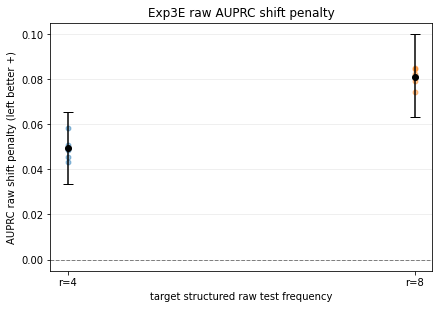

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3e_raw_shift_penalty_auprc_bootstrap_ci95.png


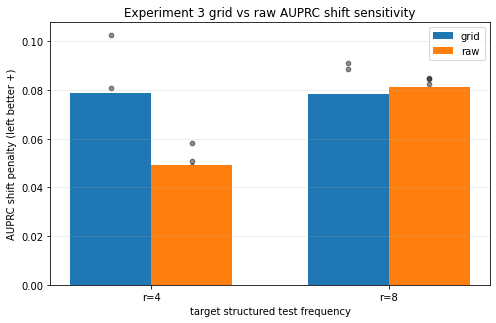

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grid_vs_raw_shift_auprc.png


In [ ]:
# ============================================================
# Exp3E concise plots
# ============================================================


def plot_raw_shift_penalty(metric="auprc"):
    if len(exp3e_raw_shift_summary) == 0:
        print("Skipping raw shift plot: no Exp3E raw summaries.")
        return
    sub = exp3e_raw_shift_summary[exp3e_raw_shift_summary["metric"] == metric].sort_values("r")
    if len(sub) == 0:
        print("Skipping raw shift plot: no rows for metric {}.".format(metric))
        return
    x = np.arange(len(sub))
    y = sub["mean_difference"].values
    lo = sub["patient_bootstrap_ci_low"].values
    hi = sub["patient_bootstrap_ci_high"].values
    yerr = np.vstack([y - lo, hi - y])
    plt.figure(figsize=(6.2, 4.4))
    plt.axhline(0, color="gray", linewidth=1, linestyle="--")
    plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=5, color="black")
    for i, r in enumerate(sub["r"].tolist()):
        raw = exp3e_raw_shift_contrasts[
            (exp3e_raw_shift_contrasts["metric"] == metric) &
            (exp3e_raw_shift_contrasts["r"].astype(int) == int(r))]
        plt.scatter(np.repeat(i, len(raw)), raw["difference"].values, alpha=0.45, s=24)
    plt.xticks(x, ["r={}".format(int(r)) for r in sub["r"].tolist()])
    plt.xlabel("target structured raw test frequency")
    plt.ylabel("{} raw shift penalty (left better +)".format(metric.upper()))
    plt.title("Exp3E raw {} shift penalty".format(metric.upper()))
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    output_path = EXP3_OUTPUT_DIR / "experiment3e_raw_shift_penalty_{}_bootstrap_ci95.png".format(metric)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


def plot_grid_vs_raw_shift(metric="auprc"):
    if len(exp3_grid_vs_raw_shift_summary) == 0:
        print("Skipping grid-vs-raw plot: no summary rows.")
        return
    sub = exp3_grid_vs_raw_shift_summary[exp3_grid_vs_raw_shift_summary["metric"] == metric].sort_values("r")
    if len(sub) == 0:
        print("Skipping grid-vs-raw plot: no rows for metric {}.".format(metric))
        return
    x = np.arange(len(sub))
    width = 0.34
    plt.figure(figsize=(7.0, 4.6))
    plt.axhline(0, color="gray", linewidth=1, linestyle="--")
    plt.bar(x - width / 2, sub["mean_grid_shift"].values, width=width, label="grid")
    plt.bar(x + width / 2, sub["mean_raw_shift"].values, width=width, label="raw")
    for i, r in enumerate(sub["r"].tolist()):
        raw = exp3_grid_vs_raw_shift_contrasts[
            (exp3_grid_vs_raw_shift_contrasts["metric"] == metric) &
            (exp3_grid_vs_raw_shift_contrasts["r"].astype(int) == int(r))]
        plt.scatter(np.repeat(i - width / 2, len(raw)), raw["grid_shift"].values, alpha=0.45, s=22, color="black")
        plt.scatter(np.repeat(i + width / 2, len(raw)), raw["raw_shift"].values, alpha=0.45, s=22, color="black")
    plt.xticks(x, ["r={}".format(int(r)) for r in sub["r"].tolist()])
    plt.xlabel("target structured test frequency")
    plt.ylabel("{} shift penalty (left better +)".format(metric.upper()))
    plt.title("Experiment 3 grid vs raw {} shift sensitivity".format(metric.upper()))
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    output_path = EXP3_OUTPUT_DIR / "experiment3_grid_vs_raw_shift_{}.png".format(metric)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


plot_raw_shift_penalty("auprc")
plot_grid_vs_raw_shift("auprc")



In [ ]:
summary_frames = [
    exp3_structured_shift_summary,
    exp3_normalizer_control_summary,
    exp3_random_shift_summary,
    exp3_horizon_replication_summary,
    exp3e_raw_shift_summary,
]
summary_frames = [df for df in summary_frames if df is not None and len(df)]
exp3_combined_key_contrast_summary = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
if len(exp3_combined_key_contrast_summary):
    final_key_cols = ["experiment", "horizon", "r", "contrast", "metric"]
    dup = exp3_combined_key_contrast_summary[
        exp3_combined_key_contrast_summary.duplicated(final_key_cols, keep=False)
    ]
    if len(dup):
        raise RuntimeError("Duplicate final contrast rows found:\n{}".format(
            dup[final_key_cols + ["left_condition", "right_condition"]]))
    inconsistent = exp3_combined_key_contrast_summary[
        (exp3_combined_key_contrast_summary["complete_seed_set"] == True) &
        (exp3_combined_key_contrast_summary["n_seeds"].astype(int) != len(EXP3_EXPECTED_MODEL_SEEDS))
    ]
    if len(inconsistent):
        raise RuntimeError("Final contrast row marked complete with n_seeds != {}:\n{}".format(
            len(EXP3_EXPECTED_MODEL_SEEDS), inconsistent[final_key_cols + ["n_seeds", "complete_seed_set"]]))
    exp3_combined_key_contrast_summary = exp3_combined_key_contrast_summary.sort_values(
        ["experiment", "horizon", "r", "metric"]
    ).reset_index(drop=True)

combined_cols = [
    "experiment", "horizon", "r", "metric", "left_condition", "right_condition",
    "left_mean", "right_mean", "mean_difference", "sd_difference", "n_seeds",
    "complete_seed_set", "patient_bootstrap_ci_low", "patient_bootstrap_ci_high",
]
show_table(
    "Experiment 3 combined key-contrast summary",
    exp3_combined_key_contrast_summary[[c for c in combined_cols if c in exp3_combined_key_contrast_summary.columns]],
    max_rows=300,
)

expected_final_contrasts = [
    ("Exp3A Structured frequency shift", 12, 4, "structured shift"),
    ("Exp3A Structured frequency shift", 12, 8, "structured shift"),
    ("Exp3B Normalizer control", 12, 4, "normalizer control"),
    ("Exp3C Random-matched frequency shift", 12, 4, "random-matched shift"),
    ("Exp3D Horizon replication", 96, 4, "structured shift"),
    ("Exp3E Raw-representation frequency shift", 12, 4, "raw structured shift"),
    ("Exp3E Raw-representation frequency shift", 12, 8, "raw structured shift"),
]
validation_rows = []
for experiment, horizon, r, contrast in expected_final_contrasts:
    for metric in EXP3_METRICS:
        present = False
        n_seeds = 0
        complete_seed_set = False
        if len(exp3_combined_key_contrast_summary):
            matches = exp3_combined_key_contrast_summary[
                (exp3_combined_key_contrast_summary["experiment"] == experiment) &
                (exp3_combined_key_contrast_summary["horizon"].astype(int) == int(horizon)) &
                (exp3_combined_key_contrast_summary["r"].astype(int) == int(r)) &
                (exp3_combined_key_contrast_summary["contrast"] == contrast) &
                (exp3_combined_key_contrast_summary["metric"] == metric)
            ]
            if len(matches) > 1:
                raise RuntimeError("Duplicate final rows for {} h={} r={} contrast={} metric={}".format(
                    experiment, horizon, r, contrast, metric))
            if len(matches) == 1:
                present = True
                n_seeds = int(matches.iloc[0]["n_seeds"])
                complete_seed_set = bool(matches.iloc[0]["complete_seed_set"])
                if complete_seed_set and n_seeds != len(EXP3_EXPECTED_MODEL_SEEDS):
                    raise RuntimeError("Final row marked complete with n_seeds={} for {} h={} r={} metric={}".format(
                        n_seeds, experiment, horizon, r, metric))
        if not present or not complete_seed_set:
            print("INCOMPLETE FINAL CONTRAST: {} h={} r={} {}".format(
                experiment, horizon, r, metric.upper()))
        validation_rows.append({
            "experiment": experiment,
            "horizon": horizon,
            "r": r,
            "contrast": contrast,
            "metric": metric,
            "present_in_final_summary": present,
            "n_seeds": n_seeds,
            "complete_seed_set": complete_seed_set,
        })

exp3_final_contrast_coverage = pd.DataFrame(validation_rows)
show_table("Experiment 3 final contrast coverage", exp3_final_contrast_coverage, max_rows=100)

grid_vs_raw_cols = [
    "r", "metric", "mean_grid_shift", "mean_raw_shift", "mean_grid_minus_raw_shift",
    "sd_grid_minus_raw_shift", "n_seeds", "complete_seed_set",
    "patient_bootstrap_ci_low", "patient_bootstrap_ci_high",
]
show_table(
    "Experiment 3 grid-vs-raw representation comparison summary",
    exp3_grid_vs_raw_shift_summary[[c for c in grid_vs_raw_cols if c in exp3_grid_vs_raw_shift_summary.columns]],
    max_rows=100,
)




Experiment 3 combined key-contrast summary


,experiment,horizon,r,metric,left_condition,right_condition,left_mean,right_mean,mean_difference,sd_difference,n_seeds,complete_seed_set,patient_bootstrap_ci_low,patient_bootstrap_ci_high
0,Exp3A Structured frequency shift,12,4,auprc,structured-r4->structured-r4,dense->structured-r4,0.476614,0.397678,0.078936,0.014574,5,True,0.060167,0.098623
1,Exp3A Structured frequency shift,12,4,auroc,structured-r4->structured-r4,dense->structured-r4,0.736053,0.679189,0.056864,0.011505,5,True,0.046936,0.067177
2,Exp3A Structured frequency shift,12,4,brier,structured-r4->structured-r4,dense->structured-r4,0.164631,0.180325,0.015694,0.004161,5,True,0.012661,0.018801
3,Exp3A Structured frequency shift,12,8,auprc,structured-r8->structured-r8,dense->structured-r8,0.450101,0.371629,0.078472,0.011074,5,True,0.057254,0.099748
4,Exp3A Structured frequency shift,12,8,auroc,structured-r8->structured-r8,dense->structured-r8,0.719811,0.651799,0.068012,0.007583,5,True,0.056095,0.079762
5,Exp3A Structured frequency shift,12,8,brier,structured-r8->structured-r8,dense->structured-r8,0.168635,0.186009,0.017375,0.002610,5,True,0.013776,0.020714
6,Exp3B Normalizer control,12,4,auprc,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.476614,0.475184,0.001430,0.005848,5,True,-0.004415,0.006905
7,Exp3B Normalizer control,12,4,auroc,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.736053,0.735366,0.000687,0.002590,5,True,-0.002889,0.004003
8,Exp3B Normalizer control,12,4,brier,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.164631,0.165139,0.000508,0.000770,5,True,-0.000435,0.001370
9,Exp3C Random-matched frequency shift,12,4,auprc,random-r4->random-r4,dense->random-r4,0.444043,0.415985,0.028058,0.006154,5,True,0.015692,0.041527



Experiment 3 final contrast coverage


,complete_seed_set,contrast,experiment,horizon,metric,n_seeds,present_in_final_summary,r
0,True,structured shift,Exp3A Structured frequency shift,12,auroc,5,True,4
1,True,structured shift,Exp3A Structured frequency shift,12,auprc,5,True,4
2,True,structured shift,Exp3A Structured frequency shift,12,brier,5,True,4
3,True,structured shift,Exp3A Structured frequency shift,12,auroc,5,True,8
4,True,structured shift,Exp3A Structured frequency shift,12,auprc,5,True,8
5,True,structured shift,Exp3A Structured frequency shift,12,brier,5,True,8
6,True,normalizer control,Exp3B Normalizer control,12,auroc,5,True,4
7,True,normalizer control,Exp3B Normalizer control,12,auprc,5,True,4
8,True,normalizer control,Exp3B Normalizer control,12,brier,5,True,4
9,True,random-matched shift,Exp3C Random-matched frequency shift,12,auroc,5,True,4



Experiment 3 grid-vs-raw representation comparison summary


,r,metric,mean_grid_shift,mean_raw_shift,mean_grid_minus_raw_shift,sd_grid_minus_raw_shift,n_seeds,complete_seed_set,patient_bootstrap_ci_low,patient_bootstrap_ci_high
0,4,auprc,0.078936,0.049300,0.029637,0.014305,5,True,0.011295,0.047867
1,4,auroc,0.056864,0.041523,0.015341,0.010170,5,True,0.005435,0.026121
2,4,brier,0.015694,0.009118,0.006576,0.003186,5,True,0.004116,0.009174
3,8,auprc,0.078472,0.081119,-0.002647,0.012735,5,True,-0.019874,0.015935
4,8,auroc,0.068012,0.067804,0.000208,0.012715,5,True,-0.010291,0.011386
5,8,brier,0.017375,0.012990,0.004385,0.002242,5,True,0.002016,0.006798


## Across-Seed Summary

The combined key-contrast table above is the compact cross-experiment summary. Structured-shift information effects remain separate because they are descriptive rather than an additive decomposition.

## Go/No-Go Interpretation

Interpret contrasts only where the intended validation-selected checkpoints and exact test-prediction files are present. Positive differences mean the left condition performs better; Brier uses the same left-better sign convention by reversing the raw lower-is-better metric.

## Source-Notebook Mapping

Exp3A preserves the original structured h=12 analysis. Exp3B adds the dense-normalizer control, Exp3C adds random-matched sampling, and Exp3D adds the h=96 structured-shift replication. All sections use the same strict provenance, exact prediction naming, automatic missing-prediction inference, same-test-example checks, and paired patient bootstrap helpers.

## Stable summary CSV exports

These exports are consumed by `visualize_summary.ipynb`. They only save dataframes already computed by this source notebook; they do not perform discovery, inference, or checkpoint selection.


In [ ]:
# SUMMARY_EXPORTS_EXP3_LSTM
SUMMARY_EXPORTS_EXP3_LSTM = {
    "exp3_train_status": "experiment3_lstm_train_status.csv",
    "exp3_train_excluded": "experiment3_lstm_train_excluded.csv",
    "exp3_run_status": "experiment3_lstm_run_status.csv",
    "exp3_missing_planned_runs": "experiment3_lstm_missing_planned_runs.csv",
    "exp3_missing_predictions": "experiment3_lstm_missing_predictions.csv",
    "exp3_run_results": "experiment3_lstm_condition_run_results.csv",
    "exp3_absolute_summary": "experiment3_lstm_absolute_summary.csv",
    "exp3_information_effects": "experiment3_lstm_information_effects_seed_level.csv",
    "exp3_information_summary": "experiment3_lstm_information_effects_summary.csv",
    "exp3_structured_shift_contrasts": "experiment3_lstm_structured_shift_seed_level.csv",
    "exp3_structured_shift_summary": "experiment3_lstm_structured_shift_summary.csv",
    "exp3_normalizer_control_contrasts": "experiment3_lstm_normalizer_control_seed_level.csv",
    "exp3_normalizer_control_summary": "experiment3_lstm_normalizer_control_summary.csv",
    "exp3_random_shift_contrasts": "experiment3_lstm_random_shift_seed_level.csv",
    "exp3_random_shift_summary": "experiment3_lstm_random_shift_summary.csv",
    "exp3_horizon_replication_contrasts": "experiment3_lstm_horizon_replication_seed_level.csv",
    "exp3_horizon_replication_summary": "experiment3_lstm_horizon_replication_summary.csv",
    "exp3e_raw_run_results": "experiment3e_lstm_raw_condition_run_results.csv",
    "exp3e_raw_absolute_summary": "experiment3e_lstm_raw_absolute_summary.csv",
    "exp3e_raw_sequence_length_summary": "experiment3e_raw_sequence_length_summary.csv",
    "exp3e_raw_shift_contrasts": "experiment3e_lstm_raw_shift_seed_level.csv",
    "exp3e_raw_shift_summary": "experiment3e_lstm_raw_shift_summary.csv",
    "exp3_grid_vs_raw_shift_contrasts": "experiment3_lstm_grid_vs_raw_shift_seed_level.csv",
    "exp3_grid_vs_raw_shift_summary": "experiment3_lstm_grid_vs_raw_shift_summary.csv",
    "exp3e_grid_matched_vs_raw_dense_contrasts": "experiment3e_lstm_grid_matched_vs_raw_dense_seed_level.csv",
    "exp3e_grid_matched_vs_raw_dense_summary": "experiment3e_lstm_grid_matched_vs_raw_dense_summary.csv",
    "exp3_combined_key_contrast_summary": "experiment3_lstm_combined_key_contrast_summary.csv",
    "exp3_final_contrast_coverage": "experiment3_lstm_final_contrast_coverage.csv",
}
for _name, _filename in SUMMARY_EXPORTS_EXP3_LSTM.items():
    _obj = globals().get(_name)
    if isinstance(_obj, pd.DataFrame):
        _path = EXP3_OUTPUT_DIR / _filename
        _obj.to_csv(_path, index=False)
        print("exported", _name, "->", _path)
    else:
        print("skipped", _name, "not available")


exported exp3_train_status -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_lstm_train_status.csv
exported exp3_train_excluded -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_lstm_train_excluded.csv
exported exp3_run_status -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_lstm_run_status.csv
exported exp3_missing_planned_runs -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_lstm_missing_planned_runs.csv
exported exp3_missing_predictions -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_lstm_missing_predictions.csv
expor